A continuacion se obtienen los resultados numericos para una red de cuatro spin-torque nano-oscillators

In [4]:
################################################################
#           STNO LIBRE (Modelo tipo Van Der Pol)               #
################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import ListedColormap


Para este primer resultado debemos considerar que no existe acoplamiento con otros osciladores (Solo tenemos 1 oscilador). Por tanto, la dinamica del sistema es gobernada por: 

$$\frac{ds}{dt}=-\alpha \omega_{0} \left( 1-\frac{I}{I_{th}}+Qs^{2} \right)s   \\ 
   
\frac{d\theta}{dt}=\omega_{0}(1+N_{0}s^{2}) $$

donde $s$ representa el radio de la orbita, $\theta$ es el angulo asociado a la posicion del vortice, $\alpha$ coeficiente de damping, $\omega_{0}$ es la frecuencia natural del STNO, $I$ es la corriente inyectada al STNO, $I_{th}$ es la corriente de umbral para que se produzca una auto-oscilacion, $Q$ parametro de damping no lineal y $N_{0}$ el corrimiento de frecuencia no lineal normalizado por la frecuencia angular natural. 

Por simplicidad trabajaremos con el tiempo adimensional, definiendo: 

$$
\tau=\omega_{0}t 
\qquad \implies \qquad 
\frac{d}{dt} = \omega_{0} \frac{d}{d\tau}
$$  

De esta manera, las ecuaciones correspondientes son tales que:

$$
\begin{aligned}
\frac{ds}{d \tau}
&=-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s,\\
\frac{d \theta}{d \tau}
&=1+N_{0}s^{2}.
\end{aligned}
$$

In [5]:
################################################################
#             Parametros (Entregados por suplemento)           #
################################################################

alpha=0.013
Q=3.02
Ith=1                                       #mA
I=1.5*Ith                                   #La corriente inyectada al inicio de la dinamica no se conoce, asi que elijo yo una
N_0=0.08

Antes de integrar y calcular la dinámica del ciclo, podemos obtener la solución
estacionaria del valor del radio de la órbita. Para ello:

$$
\frac{ds}{d\tau}=0
\qquad \implies \qquad
-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s=0.
$$

De esta manera, obtenemos dos soluciones estacionarias:

$$
s_{ss}=0,
$$

y, para la solución no trivial:

$$
s_{ss}=\sqrt{\frac{I/I_{th}-1}{Q}}.
$$

In [6]:
s_ss=np.sqrt(((I/Ith)-1)/Q)

print(f"Radio estacionario teórico: s_lc = {s_ss:.6f}")

Radio estacionario teórico: s_lc = 0.406894


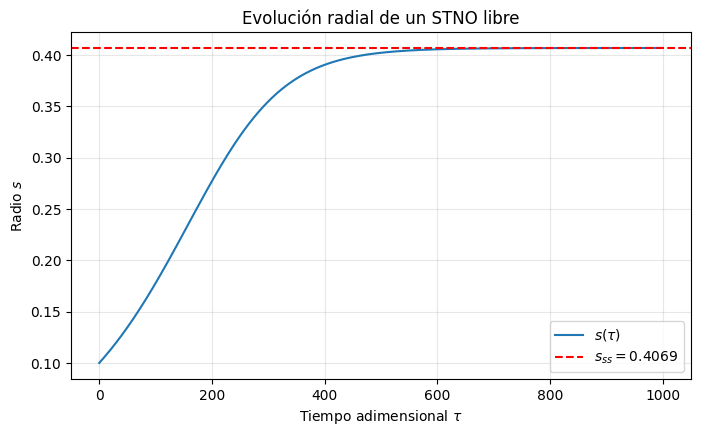

Radio final numérico:  0.406887
Radio teórico:         0.406894
Error absoluto:        7.154e-06


In [7]:
################################################################
#                     Ecuaciones diferenciales                 #
################################################################

Irazon=I/Ith

def STNO_libre(tau, y, alpha, Q, N_0, Irazon):
    s, theta=y
    ds_dtau=-alpha*(1-Irazon + Q*s**2)*s                          #Radio
    dtheta_dtau=1+N_0 * s**2                                      #Angulo
    return [ds_dtau, dtheta_dtau]                                 #Arreglo de soluciones

#Condiciones iniciales (Elecciones hechas por mi)

s_0=0.1
theta0=0
y_0=[s_0, theta0]

#Arreglo temporal

tau_0=0
tau_f=1000
tau_arreglo=np.linspace(tau_0, tau_f, 10000)

#Solucion

sol = solve_ivp(fun=STNO_libre, t_span=(tau_0, tau_f), y0=y_0, t_eval=tau_arreglo, args=(alpha, Q, N_0, Irazon), method="RK45", rtol=1e-9, atol=1e-11)

#Arreglo de soluciones

tau=sol.t
s=sol.y[0]
theta=sol.y[1]

#Grafico de la evolucion del radio de la orbita

plt.figure(figsize=(8, 4.5))
plt.plot(tau, s, label=r"$s(\tau)$")
plt.axhline(s_ss,color="red",linestyle="--",label=rf"$s_{{ss}}={s_ss:.4f}$")
plt.xlabel(r"Tiempo adimensional $\tau$")
plt.ylabel(r"Radio $s$")
plt.title("Evolución radial de un STNO libre")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Radio final numérico:  {s[-1]:.6f}")
print(f"Radio teórico:         {s_ss:.6f}")
print(f"Error absoluto:        {abs(s[-1] - s_ss):.3e}")

Ahora que ya sabemos que la solucion numerica converge a la teorica de buena manera, queremos visualizar la trayectoria de la orbita hasta la estabilidad. Para ello, utilizamos coordenadas polares tal que:

$$
x(\tau)=s(\tau)cos(\theta (\tau)) \qquad \qquad y(\tau)=s(\tau)sin(\theta (\tau))
$$

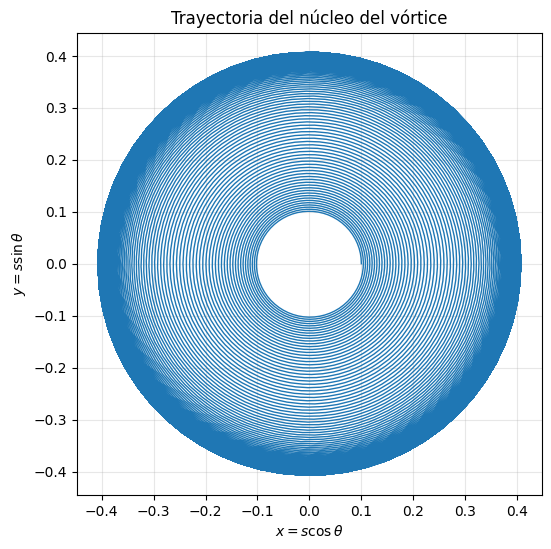

Radio inicial numérico:  0.100000
Radio final numérico:  0.406887


In [8]:
################################################################
#                         Trayectoria                          #
################################################################

x=s*np.cos(theta)
y=s*np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(x, y, linewidth=1.0, color="tab:blue")
plt.xlabel(r"$x=s\cos\theta$")
plt.ylabel(r"$y=s\sin\theta$")
plt.title("Trayectoria del núcleo del vórtice")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.show()

print(f"Radio inicial numérico:  {s[0]:.6f}")
print(f"Radio final numérico:  {s[-1]:.6f}")

Podemos observar como el radio comienza con un valor de 0.1 y evoluciona al valor estacionario 0.41, que era lo esperado. Sin embargo, para la evolucion del sistema nos interesa la parte final, es decir, la forma estacionario. Esto es porque son estas las que perduran como auto-oscilacion y posteriormente, se acoplan a frecuencias externas (Locking range). 

In [9]:
################################################################
#           Frecuencia estacionaria STNO libre                 #
################################################################

Posiciones_ss=int(0.8*len(tau))                                               #Tomo el ultimo 20% de la simulacion
tau_ss=tau[Posiciones_ss:]
theta_ss=theta[Posiciones_ss:]

Omega_num=(theta_ss[-1]-theta_ss[0])/(tau_ss[-1]-tau_ss[0])
Omega_teo=1+N_0*s_ss**2

print(f"Frecuencia angular numérica: {Omega_num:.8f}")
print(f"Frecuencia angular teórica:  {Omega_teo:.8f}")
print(f"Error absoluto: {abs(Omega_num-Omega_teo):.3e}")

Frecuencia angular numérica: 1.01324280
Frecuencia angular teórica:  1.01324503
Error absoluto: 2.230e-06


Ahora podemos analizar que sucede cuando inyectamos una frecuencia externa al sistema, llamemosla $f_{A}$ (En nuestro caso esto es representado por $\varepsilon =0$ y $F_{e} \neq 0$). De esta manera, las ecuaciones que describen el sistema son:

$$
\begin{aligned}
\frac{ds}{d \tau}
&=-\alpha \left(1-\frac{I}{I_{th}}+Qs^{2}\right)s
+F_{e}\cos{\theta}\cos(\psi_{e}-\Omega_{e}\tau)
\end{aligned}
$$

$$
\frac{d \theta}{d \tau} =1+N_{0}s^{2} + \frac{F_{e}}{s}\sin{\theta}\cos(\psi_{e}-\Omega_{e}\tau)
$$

donde $F_{e}$ es la fuerza de acoplamiento con la señal $f_{A}$, $\psi_{e}$ es el corrimiento de fase relativo (que consideraremos nulo) y $\Omega_{e}=\frac{\omega_{e}}{\omega_{0}}$ es la frecuencia angular externa normalizada.

In [10]:
################################################################
#                 Parametros de la excitacion                  #
################################################################

F_e=1.3e-3
psi_e=0
Omega_libre=Omega_teo
Omega_e=1.01                                                          #Elegimos una frecuencia angular externa ligeramente distinta a la libre
delta=Omega_e-Omega_libre                                            #Detuning

################################################################
#                 STNO con excitacion externa                  #
################################################################

def STNO_frec_ext(tau, y, alpha, Q, N_0, Irazon, F_e, Omega_e, psi_e):
    s, theta=y
    Externo= F_e*np.cos(psi_e-Omega_e*tau)
    ds_dtau=-alpha*(1-Irazon + Q*s**2)*s +Externo*np.cos(theta)                         #Radio
    dtheta_dtau=1+N_0 * s**2+ (Externo*np.sin(theta))/s                                 #Angulo
    return [ds_dtau, dtheta_dtau]                                                       #Arreglo de soluciones

################################################################
#                     Resolucion del sistema                   #
################################################################

s_0_frec_ext=s_ss                                                      #Establecemos que el radio inicial sera la frecuencia angular estacionaria (auto-oscilacion sostenida)
theta_0_frec_ext=0

#Condiciones iniciales de integracion

y_0_frec_ext=[s_0_frec_ext, theta_0_frec_ext]                 

#Arreglo temporal

tau_0=0
tau_f=5000
tau_arreglo=np.linspace(tau_0, tau_f, 50000)

#Solucion

sol_frec_ext = solve_ivp(fun=STNO_frec_ext, t_span=(tau_0, tau_f), y0=y_0_frec_ext, t_eval=tau_arreglo, args=(alpha, Q, N_0, Irazon, F_e, Omega_e, psi_e), method="RK45", rtol=1e-9, atol=1e-11)
tau_frec_ext=sol_frec_ext.t
s_frec_ext=sol_frec_ext.y[0]
theta_frec_ext=sol_frec_ext.y[1]

################################################################
#     Frecuencia estacionaria STNO con excitacion externa      #
################################################################

Posiciones_ss_frec_ext=int(0.8*len(tau_frec_ext))                                               #Tomo el ultimo 20% de la simulacion
tau_ss_frec_ext=tau_frec_ext[Posiciones_ss_frec_ext:]
theta_ss_frec_ext=theta_frec_ext[Posiciones_ss_frec_ext:]
Omega_STNO=(theta_ss_frec_ext[-1]-theta_ss_frec_ext[0])/(tau_ss_frec_ext[-1]-tau_ss_frec_ext[0])

print(f"Frecuencia libre:    {Omega_libre:.8f}")
print(f"Frecuencia externa:  {Omega_e:.8f}")
print(f"Frecuencia STNO:     {Omega_STNO:.8f}")
print("Diferencia STNO-fuente: "f"{abs(Omega_STNO - Omega_e):.3e}")


Frecuencia libre:    1.01324503
Frecuencia externa:  1.01000000
Frecuencia STNO:     1.00999825
Diferencia STNO-fuente: 1.745e-06


Notemos que el STNO libre tiene una frecuencia de oscilacion natural distinta a la frecuencia de oscilacion modificada o desplazada por la accion de la señal externa $f_{A}$. Sin embargo, no tenemos una metrica que nos permita decir que existe sincronizacion. Es por ello que ahora analizaremos la fase relativa, la cual nos dira si existe un phase locking. Se define entonces: 

$$
\phi(\tau)=\theta(\tau)-\Omega_{e}\tau+\psi_{e}
$$

En particular, se considera un corrimiento de fase relativo $\psi_{e}$ nulo. De esta manera, la fase relativa:

$$
\phi(\tau)=\theta(\tau)-\Omega_{e}\tau
$$

Si conforme pasa el tiempo $\phi \rightarrow C$ (donde $C$ es una constante) se presenta el fenomeno de phase locking, que nos indica que existe un proceso de sincronizacion en el sistema, donde el oscilar acoplado a la frecuencia externa modifica su frecuancia de oscilacion, acercandose asi a la frecuencia externa.

$$
\Omega_{STNO} \rightarrow \Omega_{e}
$$

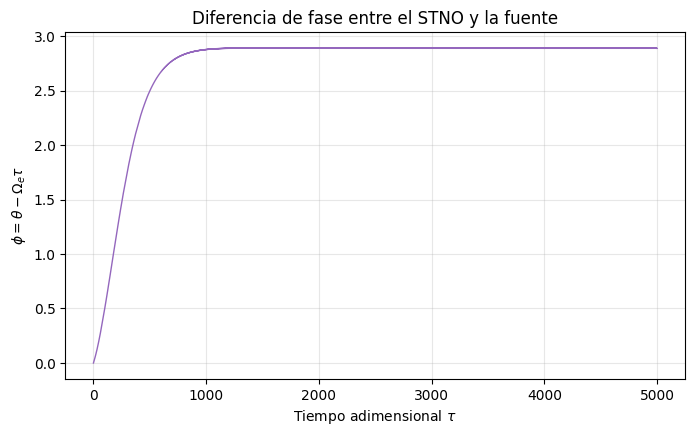

Diferencia de frecuencia STNO-fuente final: 2.887e+00


In [11]:
################################################################
#                       Fase relativa                          #
################################################################

phi=theta_frec_ext-Omega_e*tau_frec_ext 

plt.figure(figsize=(8, 4.5))
plt.plot(tau_frec_ext,phi,color="tab:purple",linewidth=1.0)
plt.xlabel(r"Tiempo adimensional $\tau$")
plt.ylabel(r"$\phi=\theta-\Omega_e\tau$")
plt.title("Diferencia de fase entre el STNO y la fuente")
plt.grid(alpha=0.3)
plt.show()

print("Diferencia de frecuencia STNO-fuente final: "f"{phi[-1]:.3e}")

Observemos que para este caso particular a partir de $\tau=1000$ aproximadamente en adelante se presenta un phase locking, lo cual queda en evidencia al comparar la diferencia de frecuencias de la frecuencia externa con la del oscilador luego de que interactuen. Sin embargo, falta determinar cual es el locking range, es decir, el rango de diferencia de frecuencias de oscilacion donde se produce un phase locking. Para ello debemos hacer un barrido de frecuencias externas y establecer un criterio de sincronizacion para asi determinar un locking range. Definimos entonces:

$$
E_{\Omega}=|\Omega_{STNO}-\Omega_{e}|
$$

Y, donde establecemos que existe un bloqueo de frecuencia para valores $E_{\Omega}< 10^{-4}$ (establezco este por que el caso analizado de phase locking entrego un $E_{\Omega} \approx 1.75^{-6}$)

In [12]:
################################################################
#         Funcion para simular frecuencias externas            #
################################################################

def sim_fe(Omega_e_i, tau_final, pasos):
    tau_evaluado=np.linspace(0, tau_final, pasos)                                     #Arreglo de tiempos
    solucion=solve_ivp(fun=STNO_frec_ext, t_span=(0.0, tau_final), y0=[s_ss, 0.0], t_eval=tau_evaluado, args=(alpha, Q, N_0, Irazon, F_e, Omega_e_i, psi_e), method="RK45", rtol=1e-8, atol=1e-10)
    tau_actual=solucion.t                                                        #Tiempo de cierto paso
    theta_actual=solucion.y[1]                                                   #Angulo de cierto tiempo
    Posiciones_ss=int(0.8*len(tau_actual))                                       #Tomamos el ultimo 20% de la simulacion
    tau_ss=tau_actual[Posiciones_ss:]                                
    theta_ss=theta_actual[Posiciones_ss:]
    Omega_STNO=(theta_ss[-1]-theta_ss[0])/(tau_ss[-1]-tau_ss[0])                 #Frecuencia de STNO en estado estacionario
    error_frec=abs(Omega_STNO-Omega_e_i)                                         #E_{\Omega}
    phi_ss=theta_ss-Omega_e_i*tau_ss                                             #Fase relativa

    #Lo que necesitamos ahora es la tasa de cambio de fase relativa. Para ello aplicare la funcion polyfit (ajuste lineal)

    pendiente_phi=np.polyfit(tau_ss, phi_ss, 1)[0]

    return Omega_STNO, error_frec, pendiente_phi

#Para corroborar que la funcion retorna los valores correctos haremos una prueba con el valor de la frecuencia externa analizada anteriormente

Omega_prueba=1.010
Omega_STNO_prueba, error_prueba, pendiente_prueba=(sim_fe(Omega_prueba, 5000, 10000))

print(f"Frecuencia externa:       {Omega_prueba:.8f}")
print(f"Frecuencia del STNO:      {Omega_STNO_prueba:.8f}")
print(f"Error de frecuencia:      {error_prueba:.3e}")
print(f"Pendiente de fase:        {pendiente_prueba:.3e}")

Frecuencia externa:       1.01000000
Frecuencia del STNO:      1.00999829
Error de frecuencia:      1.712e-06
Pendiente de fase:        -4.974e-10


Se observa un proceso de sincronizacion que cumple con la condicion correspondiente de $E_{\Omega}$.

Ahora analizaremos una red de cuatro STNOs. Las ecuaciones que gobiernan la dinamica del sistema son tal que:

$$
\frac{ds_{i}}{d\tau}=-\alpha \Omega_{0,i}(1-\frac{I}{I_{th}}+Qs_{i}^{2})s_{i}+F_{e}\cos(\theta_{i})(\cos(\psi_{A}-\Omega_{A}\tau)+\cos(\psi_{B}-\Omega_{B}\tau))+\varepsilon F_{e} \cos(\theta_{i})\sum_{j=1}^{4}s_{j}\cos(\theta_{j})
$$ 

$$
\frac{d\theta_{i}}{d\tau}=\Omega_{0,i}(1+N_{0}s_{i}^{2})+\frac{F_{e}}{s_{i}}\sin(\theta_{i})(\cos(\psi_{A}-\Omega_{A}\tau)+\cos(\psi_{B}-\Omega_{B}\tau))+\varepsilon \frac{F_{e}}{s_{i}}\sin(\theta_{i})\sum_{j=1}^{4}s_{j}\cos(\theta_{j})
$$  

Donde $\Omega_{0,1}$ son las frecuencias naturales de oscilacion de los osciladores y $\varepsilon$ es el factor de acoplamiento.

In [13]:
################################################################
#           Parametros de la red de cuatro STNOs              #
################################################################

Num_STNO=4
Omega_0=np.array([0.97, 0.99, 1.01, 1.03])
psi_A=0
psi_B=0
epsilon=1.6
radio_regularizacion=1e-6

################################################################
#       Red cartesiana equivalente para cuatro STNOs           #
################################################################

def estado_inicial_cartesiano(Irazon_red):
    radios=np.sqrt(np.maximum(Irazon_red-1.0, 0.0)/Q)
    fases=np.array([0.0, 0.05, 0.1, 0.15])
    estado_inicial=np.empty(2*Num_STNO)
    estado_inicial[0::2]=radios*np.cos(fases)
    estado_inicial[1::2]=radios*np.sin(fases)

    return estado_inicial

def red_4_STNOs_cartesiana(tau, estado, alpha, Q, N_0, Irazon, F_e, epsilon, Omega_0, Omega_A, Omega_B, psi_A, psi_B, radio_regularizacion):
    x=estado[0::2]                              #(x1,y1,...,x4,y4)
    y=estado[1::2]
    radio_cuadrado=x**2+y**2
    señal_A=np.cos(psi_A-Omega_A*tau)
    señal_B=np.cos(psi_B-Omega_B*tau)
    señal_total=señal_A+señal_B
    acopl_osc=np.sum(x)
    fuerza=F_e*(señal_total+epsilon*acopl_osc)
    amortiguamiento=-alpha*Omega_0*(1-Irazon+Q*radio_cuadrado)
    frecuencia=Omega_0*(1+N_0*radio_cuadrado)
    denominador=radio_cuadrado+radio_regularizacion**2
    cos_doble=(x**2-y**2)/denominador
    sin_doble=(2*x*y)/denominador
    
    dx_dtau=amortiguamiento*x-frecuencia*y+fuerza*cos_doble
    dy_dtau=amortiguamiento*y+frecuencia*x+fuerza*sin_doble

    derivadas=np.empty(2*Num_STNO)
    derivadas[0::2]=dx_dtau
    derivadas[1::2]=dy_dtau

    return derivadas


################################################################
#            Frecuencias libres de los cuatro STNOs            #
################################################################

Irazon_red=np.array([1.3, 1.3, 1.3, 1.3], dtype=float)
s_ss_red=np.sqrt((Irazon_red-1.0)/Q)
Omega_libres_red=Omega_0*(1.0+N_0*s_ss_red**2)

for i, Omega_libre_i in enumerate(Omega_libres_red):
    print(f"Frecuencia libre STNO {i+1}: {Omega_libre_i:.8f}")


Frecuencia libre STNO 1: 0.97770861
Frecuencia libre STNO 2: 0.99786755
Frecuencia libre STNO 3: 1.01802649
Frecuencia libre STNO 4: 1.03818543


Dado que ya tenemos la funcion que nos entregara un arreglo de soluciones tanto para el radio como el angulo podemos buscar ahora las frecuencias estacionarias de cada oscilador cuando inyectamos dos frecuencias o señales externas

In [14]:
################################################################
#             Simulacion de un punto del mapa                  #
################################################################

def frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, pasos):
    Irazon_red=np.asarray(Irazon_red, dtype=float)
    estado_inicial=estado_inicial_cartesiano(Irazon_red)
    tau_evaluado=np.linspace(0.0, tau_final, pasos)

    solucion=solve_ivp(fun=red_4_STNOs_cartesiana, t_span=(0.0, tau_final), y0=estado_inicial, t_eval=tau_evaluado, args=(alpha, Q, N_0, Irazon_red, F_e, epsilon, Omega_0, Omega_A, Omega_B, psi_A, psi_B, radio_regularizacion), method="RK45", rtol=1e-8, atol=1e-10)

    if not solucion.success:
        raise RuntimeError(f"La integracion fallo: {solucion.message}")

    x_sol=solucion.y[0::2]
    y_sol=solucion.y[1::2]
    theta_sol=np.unwrap(np.arctan2(y_sol, x_sol), axis=1)

    posicion_ss=int(0.8*len(solucion.t))
    tau_ss=solucion.t[posicion_ss:]
    theta_ss=theta_sol[:, posicion_ss:]

    Omega_STNOs=(theta_ss[:, -1]-theta_ss[:, 0])/(tau_ss[-1]-tau_ss[0])

    return Omega_STNOs, solucion.t, solucion.y


def clasificacion(Omega_STNOs, Omega_A, Omega_B, tol=0.5/350):
    patron_clas=np.zeros(Num_STNO, dtype=int)

    for i in range(Num_STNO):
        error_A=abs(Omega_STNOs[i]-Omega_A)
        error_B=abs(Omega_STNOs[i]-Omega_B)

        if error_A<tol and error_A<=error_B:
            patron_clas[i]=1
        elif error_B<tol:
            patron_clas[i]=2

    return patron_clas


def Patron_particular(Omega_A, Omega_B, Irazon_red, tau_final=5000, numero_puntos=10000, tolerancia=0.5/350):
    Omega_STNOs, _, _=frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, numero_puntos)
    patron=clasificacion(Omega_STNOs, Omega_A, Omega_B, tolerancia)

    return patron


def respuesta_red(Omega_A, Omega_B, Irazon_red,tau_final=5000.0, numero_puntos=10000,tolerancia=0.5/350):
    Omega_STNOs, _, _=frec_ss(Omega_A, Omega_B, Irazon_red, tau_final, numero_puntos)
    patron=clasificacion(Omega_STNOs, Omega_A, Omega_B, tolerancia)

    return Omega_STNOs, patron


Omega_A_prueba=Omega_libres_red[1]
Omega_B_prueba=Omega_libres_red[2]

Omega_STNOs_prueba, tau_prueba, solucion_prueba=frec_ss(Omega_A_prueba, Omega_B_prueba, Irazon_red, 5000, 10000)

patron_prueba=clasificacion(Omega_STNOs_prueba, Omega_A_prueba, Omega_B_prueba)

print("Patron de sincronizacion:", patron_prueba)
print("Frecuencias estacionarias de los STNOs:", Omega_STNOs_prueba)


Patron de sincronizacion: [0 1 2 0]
Frecuencias estacionarias de los STNOs: [0.97988412 0.99801082 1.01815327 1.04025626]


Ya tenemos una funcion para encontrar las frecuencias estacionarias de los osciladores y tambien una funcion para clasificar patrones de sincronizacion. El proximo paso es extender esto a un mapa bidimensional que muestre regiones de sincronizacion para distintos pares de frecuencias externas. Para ello, primero crearemos una funcion que nos devuelva el patron existente para un par de frecuencias externas:

Ahora, debemos asociar cada patron a una region. Para ello, notemos que cada STNO puede tener tres estados $\{0, 1, 2\}$ y, como tenemos cuatro osciladores existen $3^{4}=81$ resultados o patrones posibles. Entonces, podemos codificarlos en base 3: 

$$
P=3^{0}p_{1}+3^{1}p_{2}+3^{2}p_{3}+3^{3}p_{4} \qquad \qquad p_{i}\in \{0,1,2\}
$$

In [15]:
################################################################
#                        Codificacion                          #
################################################################

def codificacion(patron): 
    codigo=patron[0]+3*patron[1]+9*patron[2]+27*patron[3]

    return codigo

def decodificar_patron(codigo):
    codigo=int(codigo)

    return (codigo % 3, (codigo // 3) % 3, (codigo // 9) % 3, (codigo // 27) % 3)

Ahora debemos barrer un rango de frecuencias externas para generar un mapa o malla que indique los patrones de sincronización. Para representar con mayor detalle las regiones se utiliza una malla de $30\times30$.


In [ ]:
################################################################
#                            Mapa                              #
################################################################

import time
from pathlib import Path

#Parametros

Num_puntos_mapa=30                                                #Lado de malla
tau_final_mapa=5000
pasos_mapa=10000
tolerancia_mapa=0.5/350.0
Irazon_mapa=np.array([1.3, 1.3, 1.3, 1.3], dtype=float)            #Corrientes iniciales
s_ss_mapa=np.sqrt((Irazon_mapa-1.0)/Q)                             #Radios estacionarios          
Omega_libres_mapa=Omega_0*(1.0+N_0*s_ss_mapa**2)                   #Frecuencias libres estacionarias

print("Corrientes utilizadas:", Irazon_mapa)
print("Frecuencias libres:", Omega_libres_mapa)

Omega_A_val=np.linspace(Omega_libres_mapa[0]-0.01, Omega_libres_mapa[2]+0.01, Num_puntos_mapa)       #Rangos de valores de frecuencias de entrada
Omega_B_val=np.linspace(Omega_libres_mapa[1]-0.01, Omega_libres_mapa[3]+0.01, Num_puntos_mapa)

mapa_codigos=np.zeros((len(Omega_B_val), len(Omega_A_val)), dtype=int)                    #Matriz que almacenara el codigo del patron obtenido para cada par de frecuencias externas
puntos_totales=len(Omega_A_val)*len(Omega_B_val)                                          #Malla
contador=0
inicio=time.perf_counter()

for j, Omega_B_actual in enumerate(Omega_B_val):                                          #Recorremos los valores de la frecuencia externa Omega_B
    inicio_fila = time.perf_counter()
    for i, Omega_A_actual in enumerate(Omega_A_val):                                      #Para cada Omega_B recorremos todos los valores de Omega_A
        patron_actual=Patron_particular(Omega_A_actual, Omega_B_actual, Irazon_mapa, tau_final=tau_final_mapa, numero_puntos=pasos_mapa, tolerancia=tolerancia_mapa)      #Integra dinamica y obtiene estado de sincronizacion
        codigo_actual=codificacion(patron_actual)                                 
        mapa_codigos[j, i]=codigo_actual
        contador += 1

    tiempo_transcurrido=time.perf_counter()-inicio
    tiempo_fila=time.perf_counter()-inicio_fila

    #Estimacion basada en el tiempo promedio por punto calculado
    velocidad=contador/tiempo_transcurrido
    puntos_restantes=puntos_totales-contador
    segundos_restantes=puntos_restantes/velocidad

    print(f"Fila {j + 1}/{len(Omega_B_val)} terminada | " f"{contador}/{puntos_totales} puntos | " f"fila: {tiempo_fila / 60:.1f} min | " f"ETA: {segundos_restantes / 3600:.2f} h")

tiempo_total=time.perf_counter()-inicio

print("\nMapa terminado correctamente.")
print(f"Tiempo total: {tiempo_total / 3600:.2f} h")

################################################################
#                  Patrones encontrados                        #
################################################################

codigos_presentes=np.unique(mapa_codigos[mapa_codigos >= 0])            #Codigos distintos o unicos que aparecieron
patrones_encontrados={int(codigo): decodificar_patron(codigo) for codigo in codigos_presentes}      #Asocia codigo con patron

print("\nPatrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):
    print(f"Código {codigo:2d}: {patron}")

################################################################
#                  Colores y gráfico                           #
################################################################

indice_colores = np.zeros_like(mapa_codigos)

for indice, codigo in enumerate(codigos_presentes):
    indice_colores[mapa_codigos == codigo] = indice

colores=plt.cm.tab20(np.linspace(0.0, 1.0, len(codigos_presentes)))
mapa_colores = ListedColormap(colores)

plt.figure(figsize=(10, 7))

imagen=plt.imshow(indice_colores, origin="lower", aspect="auto", extent=[Omega_A_val[0], Omega_A_val[-1], Omega_B_val[0], Omega_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes) - 0.5)

plt.xlabel(r"Frecuencia de la fuente A, $\Omega_A$")
plt.ylabel(r"Frecuencia de la fuente B, $\Omega_B$")
plt.title("Regiones de sincronización de los cuatro STNOs\n" f"$I/I_{{th}}={Irazon_mapa}$")

etiquetas_patrones=[f"C{int(codigo)}: {decodificar_patron(codigo)}" for codigo in codigos_presentes]

barra_colores=plt.colorbar(imagen, ticks=np.arange(len(codigos_presentes)), pad=0.02)
barra_colores.ax.set_yticklabels(etiquetas_patrones)
barra_colores.set_label("Patrón de sincronización")

plt.tight_layout()
plt.show()

In [ ]:
################################################################
#                 Guardado del mapa calculado                  #
################################################################

np.savez_compressed("mapa_inicial_30x30.npz", mapa_codigos=mapa_codigos, Omega_A_val=Omega_A_val, Omega_B_val=Omega_B_val, Irazon_mapa=Irazon_mapa, Omega_libres_mapa=Omega_libres_mapa, tau_final_mapa=tau_final_mapa, pasos_mapa=pasos_mapa, tolerancia_mapa=tolerancia_mapa)


Se obtiene de forma exitosa un mapa de sincronización anterior al entrenamiento. En este caso los parámetros físicos controlables, correspondientes a las corrientes de polarización de los cuatro STNOs, permanecen fijos. El siguiente paso consiste en entrenar estas corrientes para desplazar las frecuencias naturales y modificar las regiones de sincronización.


Ahora debemos entrenar las corrientes alternas entrantes en los distintos STNOs. La idea es determinar la frecuencias estacionaria de la red y su respectivo patron de sincronizacion con las frecuencias entrantespara asi compararlo medianto una metrica al patron asignado a cada vocal.

Por ejemplo, para la vocal o formarte "AE", el patron que entrerga el trabajo de Julie Grolier es:

$$
(1A, 3B)
$$

Esto quiere decir que el STNO 1 se sincronizo con la frecuencia A y el STNO 3 con la frecuencia B. Mediante el entrenamiento esto se ajusta mediante el vectorde diferencia: 

$$
\mathbf d_{\mathrm{AE}}
=
\begin{pmatrix}
\Omega_A-\Omega_1\\
0\\
\Omega_B-\Omega_3\\
0
\end{pmatrix}
$$

En otras palabras, cada componente mide cuanto debe desplazar la frecuencia de un STNO particular para cierta vocal o formante.

Para los otros formantes esto es tal que: 

$$
(3A, 1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{AH}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
0\\
\Omega_A-\Omega_3\\
0
\end{pmatrix} \qquad (AH)
$$

$$
(2A, 1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{AW}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
\Omega_A-\Omega_2\\
0\\
0
\end{pmatrix} \qquad (AW)
$$

$$
(1A, 2B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{ER}}
=
\begin{pmatrix}
\Omega_A-\Omega_1\\
\Omega_B-\Omega_2\\
0\\
0
\end{pmatrix} \qquad (ER)
$$

$$
(3B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{IH}}
=
\begin{pmatrix}
0\\
0\\
\Omega_B-\Omega_3\\
0
\end{pmatrix} \qquad (IH)
$$

$$
(4B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{IY}}
=
\begin{pmatrix}
0\\
0\\
0\\
\Omega_B-\Omega_4
\end{pmatrix} \qquad (IY)
$$

$$
(1B) \qquad \rightarrow \qquad \mathbf d_{\mathrm{UW}}
=
\begin{pmatrix}
\Omega_B-\Omega_1\\
0\\
0\\
0
\end{pmatrix} \qquad (IY)
$$

Cabe la posibilidad de que en el entrenamiento obtengamos alguna sincronizacion extra que no describe correctamente a la vocal en cuestion. Para evitar esto, penalizaremos sincronizaciones "accidentales". Por ejemplo, para la vocal "AW" el patron requerido es (2,1,0,0). Imaginemos que luego del entrenamiento obtenemos la configuracion (2,1,1,0), donde los STNOs 1 y 2 son correctos pero el tercero se sincroniza accidentalmente con la frecuencia externa A. Para corregir esto debemos aumentar o disminuir la frecuencia natural del STNO 3 mediante:

$$
d_{3}=\lambda \Delta sgn(\Omega_{3}^{0}-\Omega_{A})
$$


Donde $\lambda$ es el paso que queramos (En mi caso sera igual a 1) y $\Delta$ es la tolerancia.  
Por lo cual, si: 

$$
\Omega_{3}^{0} > \Omega_{A} \rightarrow \textit{Aumentamos su frecuencia}
$$

$$
\Omega_{3}^{0} < \Omega_{A} \rightarrow \textit{Disminuimos su frecuencia}
$$


In [16]:
################################################################
#                    Vectores Diferencia                       #
################################################################
 
patrones_objetivo={                                                          #Diccionario que contiene los patrones asociados a cada vocal
    "ae": np.array([1, 0, 2, 0], dtype=int),  #(1A, 3B)
    "ah": np.array([2, 0, 1, 0], dtype=int),  #(3A, 1B)
    "aw": np.array([2, 1, 0, 0], dtype=int),  #(2A, 1B)
    "er": np.array([1, 2, 0, 0], dtype=int),  #(1A, 2B)
    "ih": np.array([0, 0, 2, 0], dtype=int),  #(3B)
    "iy": np.array([0, 0, 0, 2], dtype=int),  #(4B)
    "uw": np.array([2, 0, 0, 0], dtype=int)   #(1B)
}

def vector_diferencia(vocal,Omega_A,Omega_B,Omega_STNOs,patron,Irazon_red,tolerancia=0.5/350.0,peso_falso_positivo=1.0):
    objetivo=patrones_objetivo[vocal]                              #Patron objetivo de la vocal
    diferencia=np.zeros(Num_STNO, dtype=float)                     #Vector diferencia inicialmente nulo
    Omega_naturales=Omega_0*(1+(N_0/Q)*(Irazon_red-1))             #Frecuencias naturales de los STNOs para las corrientes actuales

    for i in range(Num_STNO):
        if objetivo[i]==1 and patron[i]!=1:                          #El STNO i debe sincronizarse con la fuente A
            diferencia[i]=Omega_A-Omega_STNOs[i]

        elif objetivo[i]==2 and patron[i]!=2:                        #El STNO i debe sincronizarse con la fuente B
            diferencia[i]=Omega_B-Omega_STNOs[i]

        #Sincronización no deseada                    
        
        elif objetivo[i]==0 and patron[i]!=0:
            if patron[i]==1:                                        #El STNO se sincronizó accidentalmente con A
                Omega_fuente=Omega_A

            elif patron[i]==2:                                      #El STNO se sincronizó accidentalmente con B
                Omega_fuente=Omega_B

            direccion=np.sign(Omega_naturales[i]-Omega_fuente)      #Direccion de la frecuencia natural del STNO respecto a la fuente no deseada

            if direccion==0:                                        #En caso de que las frecuencias sean iguales la desplazamos
                Omega_medio=0.5*(Omega_A+Omega_B)
                if Omega_fuente<=Omega_medio:
                    direccion=-1.0

                else:
                    direccion=1.0

            diferencia[i]=peso_falso_positivo*tolerancia*direccion  #Penalizamos

    return diferencia

Para seguir lo que debemos hacer ahora es cargar el dataset que contiene las frecuencias de entradas y su respectivo aporte para la construccion de una vocal. Este material contiene 37 pares de frecuencia $(f_{A}, f_{B})$ para cada una de las siete clases de vocales (Expresadas en MHz).
Como el modelo dinámico emplea frecuencias adimensionales, se define una
frecuencia de referencia

$$
f_{\mathrm{ref}}=350\ \mathrm{MHz},
$$

y se realiza la transformación

$$
\Omega_A=\frac{F_A}{f_{\mathrm{ref}}},
\qquad
\Omega_B=\frac{F_B}{f_{\mathrm{ref}}}.
$$

Debemos hacer esta transformacion por que las frecuencias externas son mucho mayores a la frecuencia interna del sistema (STNOs).

En la siguiente etapa eligiremos una muestra de cada vocal, ya que posterioemente debemos entrenar el algoritmo considerando simultaneamente las correciones de cada vocal (estan acopladas). Es decir, para cada vocal hacemos:

$$
(\Omega_A,\Omega_B)_{\text{muestra}}
\qquad \longrightarrow \qquad
\text{Integración de las ecuaciones diferenciales de los 4 STNOs}
\qquad \longrightarrow \qquad
\text{Frecuencias estacionarias de los osciladores}
$$

Luego de obtener las frecuencias de los STNOs analizamos si existe sincronizacion con alguna fuente para posteriormente comparar este resultado con el patron objetivo (patron de la vocal). Por ultimo, sumamos las diferencias exigidas en cada vocal (suma de vectores diferencia) para obtener un signo que nos dira a que lado debemos desplazar la frecuencia de un oscilador i (+, -, nulo):

$$
S=\sum_{i}d_{i}=d_{ae}+d_{ah}+d_{aw}+d_{er}+d_{ih}+d_{iy}+d_{uw}
$$

$$
D_{i}=D_i =
\begin{cases}
+1, & S_i > 0,\\
0, & S_i = 0,\\
-1, & S_i < 0.
\end{cases}
$$

In [17]:
################################################################
#                  Carga del dataset                           #
################################################################

from docx import Document

archivo_dataset=r"C:\Users\A23\Downloads\41586_2018_632_MOESM2_ESM (5).docx"
documento=Document(archivo_dataset)
tabla=documento.tables[2]                                           #La tercera tabla contiene los pares f_{A} y f_{B} de las siete vocales
datos=[]                                                            #Para guardar las filas de la tabla 3
   
for fila in tabla.rows[1:]:                                         #Guardamos las filas de la tabla (omitimos la primera porque es el encabezaedo)
    datos.append([float(celda.text.strip()) for celda in fila.cells])

datos=np.array(datos, dtype=float)                                  #Lista a arreglo

################################################################
#              Organización del dataset                        #
################################################################

vocales=["ae", "ah", "aw", "er", "ih", "iy", "uw"]
frecuencia_referencia=350.0                                         #Frecuencia para establecer unidades adimensionales de frecuencias
dataset_vocales={}                                                  #Creamos un diccionario donde cada clave sera una vocal y contendra sus respectivos 37 pares de frecuencias entrantes

for i, vocal in enumerate(vocales):
    FA=datos[:, 2*i]                                                         #Tomamos la columna referente a la frecuencia f_A y f_B
    FB=datos[:, 2*i + 1]
    Omega_A=FA/frecuencia_referencia                                         #Adimensional
    Omega_B=FB/frecuencia_referencia
    dataset_vocales[vocal]=np.column_stack((Omega_A, Omega_B))               #Construye arreglo de 37 filas y dos columnas (f_A, f_B)

################################################################
#       Selección de una muestra de cada vocal                 #
################################################################

def seleccionar_muestras(dataset_vocales):                                   #Esta funcion simplemente nos entrega muestras aleatorias para el entranmiento de cada vocal
    muestras={}

    for vocal in vocales:                                                    #Recorre cada vocal y establece una muestra
        indice=np.random.randint(len(dataset_vocales[vocal]))                #Elige aleatoriamente una de las 37 muestras para cada vocal
        muestras[vocal]=dataset_vocales[vocal][indice]                       #Se guarda el par de frecuencia externas asociada a esa muestra

    return muestras

################################################################
#        Vectores diferencia de las siete vocales              #
################################################################

def diferencias_entrenamiento(muestras, Irazon_red):
    diferencias={}                                                           #Diccionario para guardar las diferencia de cada clase

    for vocal in vocales:
        Omega_A, Omega_B=muestras[vocal]                                     #Para una vocal recuperamos el par de frecuencias externas
        Omega_STNOs, patron=respuesta_red(Omega_A, Omega_B, Irazon_red)      #Respuesta de la red al interactuar con las dos frecuencias externas
        diferencias[vocal]=vector_diferencia( vocal, Omega_A, Omega_B, Omega_STNOs, patron, Irazon_red, tolerancia=0.5/350.0, peso_falso_positivo=1.0)     #Comparamos patrones y obtenemos una diferencia de frecuencias para mcierta vocal

    return diferencias


Ahora si podemos comenzar a entrenar el modelo. Queremos que las corrientes de entreda se modifiquen por cada iteracion si es necesario. Para ello, los autores utilizan la regla:

$$
I_i^{n+1}
=
I_i^n
+
\mu D_i\,
\operatorname{sgn}\left(
\left.\frac{\partial \Omega_i}{\partial I_i}\right|_{I_i}
\right)
$$ 

Donde $\mu$ es el paso o la tasa de aprendizaje.

In [18]:
################################################################
#             Actualizacion de las corrientes                  #
################################################################

mu=0.02                                                 

def Entrenamiento(dataset_vocales, Irazon_red, mu):
    muestras=seleccionar_muestras(dataset_vocales)                     #Seleccionamos muestra aleatoria de cada vocal
    diferencias=diferencias_entrenamiento(muestras, Irazon_red)        #Simulamos red y obtenemos el vector diferencia de cada vocal
    suma_diferencias=np.sum(list(diferencias.values()), axis=0)        #Sumamos componentes de las correcciones de cada vocal
    D=np.sign(suma_diferencias)                                        #Nos da la direccion de actualizacion de la corriente

    pendiente_frecuencia=Omega_0*N_0/Q                                 #Queremos ver como responde la frecuencia libre de cada STNO frente a un cambio de corriente entrante
    signo_pendiente=np.sign(pendiente_frecuencia)

    paso=mu*D*signo_pendiente                                          #Actualizacion de corriente
    Irazon_nueva_0=Irazon_red+paso
    Irazon_nueva=np.maximum(Irazon_nueva_0, 1.0+1e-8)                  #Exijo que las nuevas corrientes de entrada no bajen de uno (I_{th}=1)


    return (Irazon_nueva, muestras, diferencias, suma_diferencias, D)

Recordemos que al modificar las corrientes entrantes tambien cambian las frecuencias naturales de los STNOs: 

$$
\Omega_{i}=\Omega_{0,i}\left[ 1+\frac{N_0}{Q}(I_{i}-1) \right]
$$

Por lo tanto, la region de sincronizacion tambien debe desplazarse. La idea del entrenamiento es mover estas regiones hasta que los conjuntos asociados a cada vocal produzcan los patrones correspondientes.

In [19]:
################################################################
#                        Entrenamiento                         #
################################################################

def entrenar_red(dataset_vocales, Irazon_inicial, mu, N_iteraciones):
    Irazon_actual=np.array(Irazon_inicial, dtype=float).copy()
    historial_corrientes=[Irazon_actual.copy()]                               #Guardamos corrientes iniciales
    historial_D=[]                                                            #Guardamos signo 
    historial_sumas=[]                                                        #Guardamos suma de vectores diferencia

    for iteracion in range(N_iteraciones):
        resultado=Entrenamiento(dataset_vocales, Irazon_actual, mu)           #Ciclo de iteraciones
        (Irazon_nueva, muestras, diferencias, suma_diferencias, D)=resultado

        historial_corrientes.append(Irazon_nueva.copy())                      #Guardamos
        historial_D.append(D.copy())
        historial_sumas.append(suma_diferencias.copy())

        Irazon_actual=Irazon_nueva                                            #Actualizamos corrientes de entrada

        print(f"Iteración {iteracion + 1}: "f"I/Ith = {Irazon_actual}")

    return (Irazon_actual, np.array(historial_corrientes), np.array(historial_D), np.array(historial_sumas))


En resumen, cada muestra de entrenamiento corresponde a una vocal representada por sus dos
frecuencias características, normalizadas como $(\Omega_A,\Omega_B)$. Estas
frecuencias se introducen en la red mediante dos señales externas de microondas.

$$
\text{Vocal}
\quad \longrightarrow \quad
(\Omega_A,\Omega_B)
\quad \longrightarrow \quad
\text{Dos señales externas aplicadas a los cuatro STNOs}
$$

Para el estado actual de las corrientes de polarización
$(I_1,I_2,I_3,I_4)$, se integran las ecuaciones dinámicas de los cuatro
osciladores. Cada corriente determina la frecuencia natural del STNO
correspondiente y, por lo tanto, modifica su capacidad para sincronizarse con
alguna de las fuentes externas.

$$
(I_1,I_2,I_3,I_4)
\quad \longrightarrow \quad
(\Omega_1^{(0)},\Omega_2^{(0)},\Omega_3^{(0)},\Omega_4^{(0)})
$$

$$
\left.
\begin{array}{c}
(\Omega_A,\Omega_B)\\[2mm]
(\Omega_1^{(0)},\Omega_2^{(0)},\Omega_3^{(0)},\Omega_4^{(0)})
\end{array}
\right\}
\quad \longrightarrow \quad
\text{Evolución dinámica de los cuatro STNOs}
\quad \longrightarrow \quad
(\Omega_1,\Omega_2,\Omega_3,\Omega_4)
$$

Una vez alcanzado el régimen estacionario, las frecuencias finales se comparan
con las frecuencias externas para determinar el patrón de sincronización:

$$
\Omega_i \approx
\begin{cases}
\Omega_A, & \text{STNO }i\text{ sincronizado con la fuente A},\\[1mm]
\Omega_B, & \text{STNO }i\text{ sincronizado con la fuente B},\\[1mm]
\Omega_i^{(0)}, & \text{STNO }i\text{ no sincronizado}
\end{cases}
$$

El patrón obtenido se compara con el patrón objetivo asociado a la vocal. Si
algún STNO no presenta la sincronización deseada, se calcula una corrección
$D_i$ y se modifica su corriente de polarización:

$$
I_i^{n+1}
=
I_i^n
+
\mu D_i
\operatorname{sgn}
\left(
\frac{\partial\Omega_i}{\partial I_i}
\right)_{I_i^n}
$$

En esta regla, $\mu$ controla el tamaño del paso de aprendizaje, mientras que
$D_i$ indica la dirección en que debe desplazarse la frecuencia del oscilador.
El signo de $\partial\Omega_i/\partial I_i$ permite traducir esa corrección de
frecuencia en una corrección de corriente.

Por lo tanto, cada iteración del entrenamiento sigue el ciclo

$$
\boxed{\text{Muestra }(\Omega_A,\Omega_B)}
\quad \longrightarrow \quad
\boxed{\text{Integración de la dinámica}}
\quad \longrightarrow \quad
\boxed{\text{Patrón de sincronización obtenido}}
$$

$$
\longrightarrow \quad
\boxed{\text{Comparación con el patrón objetivo}}
\quad \longrightarrow \quad
\boxed{\text{Corrección de las corrientes}}
\quad \longrightarrow \quad
\boxed{\text{Nuevas frecuencias naturales}}
$$

Este procedimiento se repite para todas las muestras y durante varias épocas:

$$
\text{Múltiples épocas de entrenamiento}
\quad \longrightarrow \quad
\text{Ajuste progresivo de }(I_1,I_2,I_3,I_4)
\quad \longrightarrow \quad
\text{Regiones de sincronización asociadas a las vocales}.
$$



In [ ]:
################################################################
#         Entrenamiento completo con penalizacion              #
################################################################

import time

np.random.seed(42)

tolerancia_paper=0.5/350.0
Irazon_inicial_paper=np.array([1.3, 1.3, 1.3, 1.3],dtype=float)
N_iteraciones_paper=87
inicio_entrenamiento_paper=time.perf_counter()
(Irazon_final_paper,historial_corrientes_paper_completo,historial_D_paper_completo,historial_sumas_paper_completo)=entrenar_red(dataset_vocales,Irazon_inicial_paper,mu,N_iteraciones_paper)
tiempo_entrenamiento_paper=(time.perf_counter()-inicio_entrenamiento_paper)
historial_frecuencias_paper_completo=Omega_0[None, :]*(1.0+(N_0/Q)*(historial_corrientes_paper_completo-1.0))

print("\nEntrenamiento completo terminado.")
print("Corrientes iniciales:", Irazon_inicial_paper)
print("Corrientes finales:  ", Irazon_final_paper)
print(f"Tiempo total: "f"{tiempo_entrenamiento_paper/3600:.2f} h")

Iteración 1: I/Ith = [1.28 1.28 1.28 1.28]
Iteración 2: I/Ith = [1.28 1.26 1.26 1.26]
Iteración 3: I/Ith = [1.26 1.26 1.24 1.24]
Iteración 4: I/Ith = [1.24 1.26 1.22 1.22]
Iteración 5: I/Ith = [1.22 1.24 1.22 1.2 ]
Iteración 6: I/Ith = [1.2  1.22 1.2  1.18]
Iteración 7: I/Ith = [1.18 1.2  1.18 1.18]
Iteración 8: I/Ith = [1.18 1.2  1.18 1.18]
Iteración 9: I/Ith = [1.18 1.18 1.16 1.16]
Iteración 10: I/Ith = [1.18 1.18 1.16 1.14]
Iteración 11: I/Ith = [1.18 1.18 1.14 1.14]
Iteración 12: I/Ith = [1.2  1.16 1.12 1.12]
Iteración 13: I/Ith = [1.18 1.14 1.1  1.12]
Iteración 14: I/Ith = [1.18 1.12 1.08 1.12]
Iteración 15: I/Ith = [1.18 1.12 1.1  1.12]
Iteración 16: I/Ith = [1.18 1.12 1.1  1.12]
Iteración 17: I/Ith = [1.18 1.12 1.1  1.12]
Iteración 18: I/Ith = [1.16 1.14 1.08 1.12]
Iteración 19: I/Ith = [1.18 1.14 1.1  1.12]
Iteración 20: I/Ith = [1.2  1.14 1.12 1.12]
Iteración 21: I/Ith = [1.18 1.14 1.12 1.12]
Iteración 22: I/Ith = [1.18 1.16 1.14 1.12]
Iteración 23: I/Ith = [1.16 1.14 1.14 1.1

In [18]:
################################################################
#     Guardado del entrenamiento completo ya realizado         #
################################################################

np.savez_compressed(
    "entrenamiento_STNOs_87_tolerancia_paper.npz",
    Irazon_inicial=Irazon_inicial_paper,
    Irazon_final=Irazon_final_paper,
    historial_corrientes=historial_corrientes_paper_completo,
    historial_frecuencias=historial_frecuencias_paper_completo,
    historial_D=historial_D_paper_completo,
    historial_sumas=historial_sumas_paper_completo,
    mu=mu,
    tolerancia=tolerancia_paper,
    tiempo_entrenamiento=tiempo_entrenamiento_paper
)

print("Entrenamiento completo guardado correctamente.")


NameError: name 'Irazon_inicial_paper' is not defined

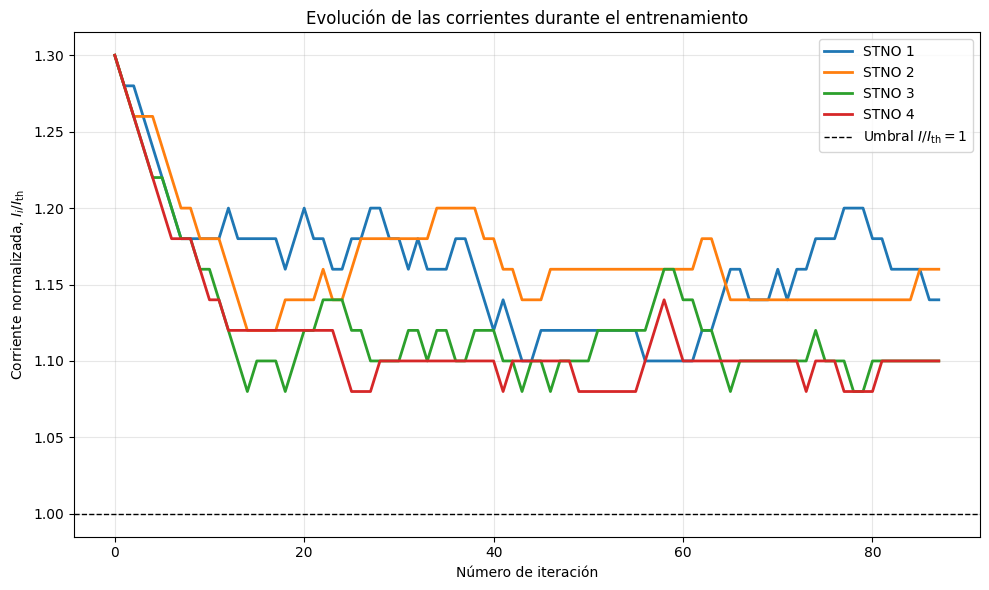

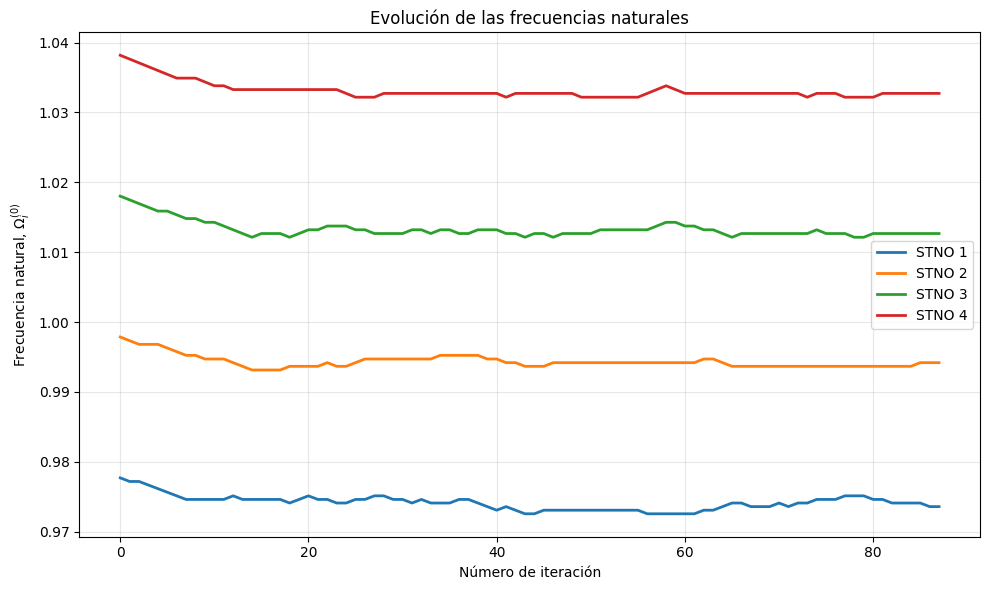

Frecuencias naturales iniciales:
[0.97770861 0.99786755 1.01802649 1.03818543]

Frecuencias naturales finales:
[0.97359735 0.99419603 1.0126755  1.03272848]


In [ ]:
################################################################
#              Evolución de las corrientes                    #
################################################################

iteraciones=np.arange(len(historial_corrientes_paper_completo))

plt.figure(figsize=(10, 6))

for i in range(Num_STNO):
    plt.plot(iteraciones, historial_corrientes_paper_completo[:, i], linewidth=2, label=f"STNO {i + 1}")

plt.axhline(1.0,color="black",linestyle="--",linewidth=1,label=r"Umbral $I/I_{\mathrm{th}}=1$")
plt.xlabel("Número de iteración")
plt.ylabel(r"Corriente normalizada, $I_i/I_{\mathrm{th}}$")
plt.title("Evolución de las corrientes durante el entrenamiento")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

################################################################
#          Evolución de las frecuencias naturales             #
################################################################

plt.figure(figsize=(10, 6))

for i in range(Num_STNO):
    plt.plot(iteraciones,historial_frecuencias_paper_completo[:, i],linewidth=2,label=f"STNO {i + 1}")
    
plt.xlabel("Número de iteración")
plt.ylabel(r"Frecuencia natural, $\Omega_i^{(0)}$")
plt.title("Evolución de las frecuencias naturales")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Frecuencias naturales iniciales:")
print(historial_frecuencias_paper_completo[0])

print("\nFrecuencias naturales finales:")
print(historial_frecuencias_paper_completo[-1])

In [ ]:
################################################################
#       Evaluación completa de la configuración entrenada      #
################################################################

import time

Irazon_evaluacion=Irazon_final_paper.copy()
aciertos_totales=0
muestras_totales=0
aciertos_por_vocal={}
patrones_por_vocal={}
inicio_evaluacion=time.perf_counter()

for vocal in vocales:
    objetivo=patrones_objetivo[vocal]
    aciertos_vocal=0
    patrones_por_vocal[vocal]=[]
    for indice, entrada in enumerate(dataset_vocales[vocal]):
        Omega_A, Omega_B=entrada
        patron_obtenido=Patron_particular(Omega_A, Omega_B, Irazon_evaluacion, tau_final=5000.0, numero_puntos=10000, tolerancia=0.5/350)
        correcto=np.array_equal(patron_obtenido, objetivo)
        patrones_por_vocal[vocal].append(patron_obtenido.copy())
        aciertos_vocal += int(correcto)
        aciertos_totales += int(correcto)
        muestras_totales += 1

    aciertos_por_vocal[vocal]=aciertos_vocal
    tiempo_transcurrido=(time.perf_counter()-inicio_evaluacion)
    velocidad=muestras_totales/tiempo_transcurrido
    puntos_restantes=(7*len(dataset_vocales[vocal])-muestras_totales)
    segundos_restantes=puntos_restantes/velocidad

    print(f"{vocal.upper()} | "f"{aciertos_vocal}/{len(dataset_vocales[vocal])} | "f"exactitud: "f"{100*aciertos_vocal/len(dataset_vocales[vocal]):.1f}% | "f"ETA: {segundos_restantes/3600:.2f} h")

exactitud_total=(100.0*aciertos_totales/muestras_totales)
tiempo_total_evaluacion=(time.perf_counter()-inicio_evaluacion)

print("\nEvaluación terminada.")
print(f"Exactitud total: "f"{aciertos_totales}/{muestras_totales} "f"= {exactitud_total:.1f}%")
print(f"Tiempo total: "f"{tiempo_total_evaluacion/3600:.2f} h")

AE | 28/37 | exactitud: 75.7% | ETA: 1.83 h
AH | 20/37 | exactitud: 54.1% | ETA: 1.48 h
AW | 24/37 | exactitud: 64.9% | ETA: 1.17 h
ER | 26/37 | exactitud: 70.3% | ETA: 0.87 h
IH | 37/37 | exactitud: 100.0% | ETA: 0.58 h
IY | 32/37 | exactitud: 86.5% | ETA: 0.29 h
UW | 35/37 | exactitud: 94.6% | ETA: 0.00 h

Evaluación terminada.
Exactitud total: 202/259 = 78.0%
Tiempo total: 2.04 h


In [29]:
################################################################
#              Guardado de la evaluación completa             #
################################################################

patrones_por_vocal_guardado={
    vocal: np.array(patrones_por_vocal[vocal], dtype=int)
    for vocal in vocales
}

np.savez_compressed(
    "evaluacion_completa_87_iteraciones.npz",
    Irazon_evaluacion=Irazon_evaluacion,
    tolerancia=0.5/350,
    vocales=np.array(vocales),
    aciertos_por_vocal=np.array(
        [aciertos_por_vocal[vocal] for vocal in vocales]
    ),
    patrones_por_vocal=np.array(
        [patrones_por_vocal_guardado[vocal] for vocal in vocales]
    ),
    aciertos_totales=aciertos_totales,
    muestras_totales=muestras_totales,
    exactitud_total=exactitud_total,
    tiempo_total_evaluacion=tiempo_total_evaluacion
)

print("Evaluación completa guardada correctamente.")

Evaluación completa guardada correctamente.


In [ ]:
################################################################
#        Patrones obtenidos para cada clase de vocal           #
################################################################

from collections import Counter

for vocal in vocales:
    patrones_vocal=[tuple(patron)for patron in patrones_por_vocal[vocal]]
    conteo_patrones=Counter(patrones_vocal)
    objetivo=tuple(patrones_objetivo[vocal])

    print(f"\n{vocal.upper()} | objetivo: {objetivo}")

    for patron, cantidad in conteo_patrones.most_common():
        porcentaje=100.0*cantidad/len(patrones_vocal)
        print(f"{patron}: "f"{cantidad}/37 "f"({porcentaje:.1f}%)")


AE | objetivo: (np.int64(1), np.int64(0), np.int64(2), np.int64(0))
(np.int64(1), np.int64(0), np.int64(2), np.int64(0)): 28/37 (75.7%)
(np.int64(0), np.int64(0), np.int64(2), np.int64(0)): 9/37 (24.3%)

AH | objetivo: (np.int64(2), np.int64(0), np.int64(1), np.int64(0))
(np.int64(2), np.int64(0), np.int64(1), np.int64(0)): 20/37 (54.1%)
(np.int64(0), np.int64(0), np.int64(1), np.int64(0)): 5/37 (13.5%)
(np.int64(2), np.int64(0), np.int64(0), np.int64(0)): 4/37 (10.8%)
(np.int64(2), np.int64(1), np.int64(1), np.int64(0)): 3/37 (8.1%)
(np.int64(0), np.int64(1), np.int64(0), np.int64(0)): 2/37 (5.4%)
(np.int64(0), np.int64(1), np.int64(1), np.int64(0)): 1/37 (2.7%)
(np.int64(2), np.int64(0), np.int64(0), np.int64(1)): 1/37 (2.7%)
(np.int64(0), np.int64(2), np.int64(0), np.int64(0)): 1/37 (2.7%)

AW | objetivo: (np.int64(2), np.int64(1), np.int64(0), np.int64(0))
(np.int64(2), np.int64(1), np.int64(0), np.int64(0)): 24/37 (64.9%)
(np.int64(2), np.int64(1), np.int64(1), np.int64(0)): 6/37

In [2]:
################################################################
#          Corrientes finales ya entrenadas                    #
################################################################

Irazon_final_paper=np.array(
    [1.14, 1.16, 1.10, 1.10],
    dtype=float
)

In [ ]:
################################################################
#       Mapa entrenado con vocales y frecuencias en MHz        #
################################################################

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

################################################################
#                  Parámetros del mapa                         #
################################################################

Num_puntos_mapa=30
tau_final_mapa=5000
pasos_mapa=10000
frecuencia_referencia=350.0
tolerancia_mapa=0.5/frecuencia_referencia
Irazon_mapa=np.array(Irazon_final_paper,dtype=float).copy()
s_ss_mapa=np.sqrt(np.maximum(Irazon_mapa-1.0, 0.0)/Q)
Omega_libres_mapa=Omega_0*(1.0+N_0*s_ss_mapa**2)

f_libres_mapa=(frecuencia_referencia*Omega_libres_mapa)
print("Corrientes utilizadas:")
print(Irazon_mapa)
print("\nFrecuencias naturales adimensionales:")
print(Omega_libres_mapa)
print("\nFrecuencias naturales en MHz:")
print(f_libres_mapa)
print("\nTolerancia adimensional:",tolerancia_mapa)
print("Tolerancia física:",frecuencia_referencia*tolerancia_mapa,"MHz") 

################################################################
#          Rango que contiene todas las vocales                #
################################################################

todas_entradas=np.vstack([dataset_vocales[vocal] for vocal in vocales])
margen_mapa=0.005
Omega_A_min=(todas_entradas[:, 0].min()-margen_mapa)
Omega_A_max=(todas_entradas[:, 0].max()+margen_mapa)
Omega_B_min=(todas_entradas[:, 1].min()-margen_mapa)
Omega_B_max=(todas_entradas[:, 1].max()+margen_mapa)
Omega_A_val=np.linspace(Omega_A_min, Omega_A_max, Num_puntos_mapa)
Omega_B_val=np.linspace(Omega_B_min, Omega_B_max, Num_puntos_mapa)

f_A_val=frecuencia_referencia*Omega_A_val
f_B_val=frecuencia_referencia*Omega_B_val

print("\nRango del mapa:")
print(f"Fuente A: "f"{f_A_val[0]:.2f} a "f"{f_A_val[-1]:.2f} MHz")
print(f"Fuente B: "f"{f_B_val[0]:.2f} a "f"{f_B_val[-1]:.2f} MHz")

################################################################
#                  Construcción del mapa                       #
################################################################

mapa_codigos=np.zeros((len(Omega_B_val), len(Omega_A_val)),dtype=int)
puntos_totales=(len(Omega_A_val)*len(Omega_B_val))
contador=0
inicio_mapa=time.perf_counter()

for j, Omega_B_actual in enumerate(Omega_B_val):
    inicio_fila=time.perf_counter()
    for i, Omega_A_actual in enumerate(Omega_A_val):
        patron_actual=Patron_particular(Omega_A_actual, Omega_B_actual, Irazon_mapa, tau_final=tau_final_mapa, numero_puntos=pasos_mapa, tolerancia=tolerancia_mapa)
        codigo_actual=codificacion(patron_actual)
        mapa_codigos[j, i]=codigo_actual
        contador += 1

    tiempo_transcurrido=(time.perf_counter()-inicio_mapa)
    tiempo_fila=(time.perf_counter()-inicio_fila)
    velocidad=contador/tiempo_transcurrido
    puntos_restantes=(puntos_totales-contador)
    segundos_restantes=(puntos_restantes/velocidad)

    print(f"Fila {j + 1}/{len(Omega_B_val)} terminada | "f"{contador}/{puntos_totales} puntos | "f"fila: {tiempo_fila/60:.1f} min | "f"ETA: {segundos_restantes/3600:.2f} h")

tiempo_total_mapa=(time.perf_counter()-inicio_mapa)

print("\nMapa entrenado terminado correctamente.")
print(f"Tiempo total: "f"{tiempo_total_mapa/3600:.2f} h"

################################################################
#                   Patrones encontrados                       #
################################################################

codigos_presentes=np.unique(mapa_codigos)
patrones_encontrados={int(codigo): decodificar_patron(codigo) for codigo in codigos_presentes}

print("\nPatrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):
    print(f"Código {codigo:2d}: {patron}")


################################################################
#           Preparación de los colores del mapa                #
################################################################

indice_colores=np.zeros_like(mapa_codigos)

for indice, codigo in enumerate(codigos_presentes):
    indice_colores[mapa_codigos == codigo]=indice

colores_regiones=plt.cm.tab20(np.linspace(0.0, 1.0, len(codigos_presentes)))
mapa_colores=ListedColormap(colores_regiones)

################################################################
#       Gráfico del mapa entrenado con las siete vocales       #
################################################################

figura, eje=plt.subplots(figsize=(12, 8))
imagen=eje.imshow(indice_colores, origin="lower", aspect="auto", extent=[f_A_val[0], f_A_val[-1], f_B_val[0], f_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes)-0.5)
eje.set_xlabel(r"Frecuencia de la fuente A, $f_A$ (MHz)")
eje.set_ylabel(r"Frecuencia de la fuente B, $f_B$ (MHz)")
texto_corrientes=", ".join(f"{corriente:.2f}" for corriente in Irazon_mapa)
eje.set_title("Mapa de sincronización posterior al entrenamiento\n"rf"$I/I_{{\mathrm{{th}}}}="rf"({texto_corrientes})$")

################################################################
#                  Nubes de las vocales                        #
################################################################

colores_vocales=plt.cm.tab10(np.linspace(0.0,1.0,len(vocales)))
marcadores_vocales=["o", "s", "^", "D", "P", "X", "v"]

for vocal, color, marcador in zip(vocales, colores_vocales, marcadores_vocales):
    f_A_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 0])  #Conversión de las entradas adimensionales a MHz
    f_B_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 1])
    eje.scatter(f_A_vocal, f_B_vocal, s=42, marker=marcador, color=color, edgecolors="black", linewidths=0.5, alpha=0.9, label=vocal.upper(), zorder=3)


################################################################
#             Leyenda y barra de patrones                      #
################################################################

eje.legend(title="Vocal", loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
etiquetas_patrones=[(f"C{int(codigo)}: "f"{decodificar_patron(codigo)}") for codigo in codigos_presentes]
barra_colores=figura.colorbar(imagen, ax=eje, ticks=np.arange(len(codigos_presentes)), pad=0.20)
barra_colores.ax.set_yticklabels(etiquetas_patrones)
barra_colores.set_label("Patrón de sincronización")
eje.grid(alpha=0.15, color="black")
figura.tight_layout()
plt.show()

################################################################
#              Guardado del mapa entrenado                     #
################################################################

np.savez_compressed(
    "mapa_entrenado_30x30_MHz_penalizacion.npz",
    mapa_codigos=mapa_codigos,
    Omega_A_val=Omega_A_val,
    Omega_B_val=Omega_B_val,
    f_A_val=f_A_val,
    f_B_val=f_B_val,
    Irazon_mapa=Irazon_mapa,
    Omega_libres_mapa=Omega_libres_mapa,
    f_libres_mapa=f_libres_mapa,
    tolerancia_mapa=tolerancia_mapa,
    frecuencia_referencia=frecuencia_referencia,
    tau_final_mapa=tau_final_mapa,
    pasos_mapa=pasos_mapa,
    tiempo_total_mapa=tiempo_total_mapa)

print("\nMapa entrenado guardado correctamente en:")
print("mapa_entrenado_30x30_MHz_penalizacion.npz")

Corrientes utilizadas:
[1.14 1.16 1.1  1.1 ]

Frecuencias naturales adimensionales:
[0.97359735 0.99419603 1.0126755  1.03272848]

Frecuencias naturales en MHz:
[340.75907285 347.96860927 354.43642384 361.45496689]

Tolerancia adimensional: 0.0014285714285714286
Tolerancia física: 0.5 MHz

Rango del mapa:
Fuente A: 326.82 a 360.38 MHz
Fuente B: 337.47 a 364.74 MHz
Fila 1/30 terminada | 30/900 puntos | fila: 15.4 min | ETA: 7.43 h
Fila 2/30 terminada | 60/900 puntos | fila: 17.2 min | ETA: 7.60 h
Fila 3/30 terminada | 90/900 puntos | fila: 16.8 min | ETA: 7.41 h
Fila 4/30 terminada | 120/900 puntos | fila: 14.9 min | ETA: 6.96 h
Fila 5/30 terminada | 150/900 puntos | fila: 13.8 min | ETA: 6.51 h
Fila 6/30 terminada | 180/900 puntos | fila: 14.2 min | ETA: 6.15 h
Fila 7/30 terminada | 210/900 puntos | fila: 14.3 min | ETA: 5.84 h
Fila 8/30 terminada | 240/900 puntos | fila: 14.2 min | ETA: 5.54 h
Fila 9/30 terminada | 270/900 puntos | fila: 15.8 min | ETA: 5.31 h
Fila 10/30 terminada | 3

NameError: name 'decodificar_patron' is not defined


Patrones de sincronización encontrados:
Código  0: (0, 0, 0, 0)
Código  1: (1, 0, 0, 0)
Código  2: (2, 0, 0, 0)
Código  3: (0, 1, 0, 0)
Código  4: (1, 1, 0, 0)
Código  5: (2, 1, 0, 0)
Código  6: (0, 2, 0, 0)
Código  7: (1, 2, 0, 0)
Código  8: (2, 2, 0, 0)
Código  9: (0, 0, 1, 0)
Código 11: (2, 0, 1, 0)
Código 12: (0, 1, 1, 0)
Código 14: (2, 1, 1, 0)
Código 15: (0, 2, 1, 0)
Código 18: (0, 0, 2, 0)
Código 19: (1, 0, 2, 0)
Código 21: (0, 1, 2, 0)
Código 24: (0, 2, 2, 0)
Código 25: (1, 2, 2, 0)
Código 27: (0, 0, 0, 1)
Código 29: (2, 0, 0, 1)
Código 33: (0, 2, 0, 1)
Código 36: (0, 0, 1, 1)
Código 45: (0, 0, 2, 1)
Código 54: (0, 0, 0, 2)
Código 55: (1, 0, 0, 2)
Código 57: (0, 1, 0, 2)
Código 63: (0, 0, 1, 2)
Código 66: (0, 1, 1, 2)
Código 72: (0, 0, 2, 2)
Código 75: (0, 1, 2, 2)


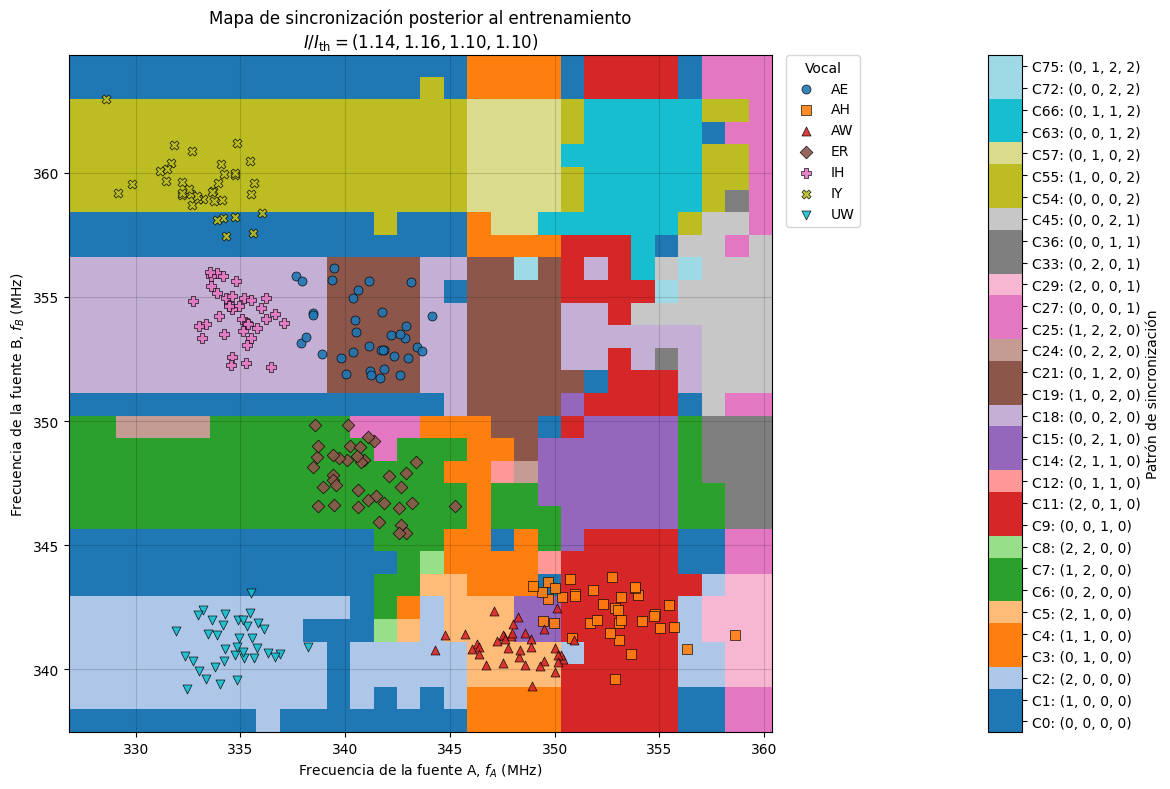


Mapa entrenado guardado correctamente en:
mapa_entrenado_30x30_MHz_penalizacion.npz


In [ ]:
################################################################
#                   Patrones encontrados                       #
################################################################

codigos_presentes=np.unique(mapa_codigos)
patrones_encontrados={int(codigo): decodificar_patron(codigo) for codigo in codigos_presentes}

print("\nPatrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):
    print(f"Código {codigo:2d}: {patron}")


################################################################
#           Preparación de los colores del mapa                #
################################################################

indice_colores=np.zeros_like(mapa_codigos)

for indice, codigo in enumerate(codigos_presentes):
    indice_colores[mapa_codigos == codigo]=indice

colores_regiones=plt.cm.tab20(np.linspace(0.0, 1.0, len(codigos_presentes)))
mapa_colores=ListedColormap(colores_regiones)

################################################################
#       Gráfico del mapa entrenado con las siete vocales       #
################################################################

figura, eje=plt.subplots(figsize=(12, 8))
imagen=eje.imshow(indice_colores, origin="lower", aspect="auto", extent=[f_A_val[0], f_A_val[-1], f_B_val[0], f_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes)-0.5)
eje.set_xlabel(r"Frecuencia de la fuente A, $f_A$ (MHz)")
eje.set_ylabel(r"Frecuencia de la fuente B, $f_B$ (MHz)")
texto_corrientes=", ".join(f"{corriente:.2f}" for corriente in Irazon_mapa)
eje.set_title("Mapa de sincronización posterior al entrenamiento\n"rf"$I/I_{{\mathrm{{th}}}}="rf"({texto_corrientes})$")

################################################################
#                  Nubes de las vocales                        #
################################################################

colores_vocales=plt.cm.tab10(np.linspace(0.0,1.0,len(vocales)))
marcadores_vocales=["o", "s", "^", "D", "P", "X", "v"]

for vocal, color, marcador in zip(vocales, colores_vocales, marcadores_vocales):
    f_A_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 0])  #Conversión de las entradas adimensionales a MHz
    f_B_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 1])
    eje.scatter(f_A_vocal, f_B_vocal, s=42, marker=marcador, color=color, edgecolors="black", linewidths=0.5, alpha=0.9, label=vocal.upper(), zorder=3)


################################################################
#             Leyenda y barra de patrones                      #
################################################################

eje.legend(title="Vocal", loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
etiquetas_patrones=[(f"C{int(codigo)}: "f"{decodificar_patron(codigo)}") for codigo in codigos_presentes]
barra_colores=figura.colorbar(imagen, ax=eje, ticks=np.arange(len(codigos_presentes)), pad=0.20)
barra_colores.ax.set_yticklabels(etiquetas_patrones)
barra_colores.set_label("Patrón de sincronización")
eje.grid(alpha=0.15, color="black")
figura.tight_layout()
plt.show()

################################################################
#              Guardado del mapa entrenado                     #
################################################################

np.savez_compressed(
    "mapa_entrenado_30x30_MHz_penalizacion.npz",
    mapa_codigos=mapa_codigos,
    Omega_A_val=Omega_A_val,
    Omega_B_val=Omega_B_val,
    f_A_val=f_A_val,
    f_B_val=f_B_val,
    Irazon_mapa=Irazon_mapa,
    Omega_libres_mapa=Omega_libres_mapa,
    f_libres_mapa=f_libres_mapa,
    tolerancia_mapa=tolerancia_mapa,
    frecuencia_referencia=frecuencia_referencia,
    tau_final_mapa=tau_final_mapa,
    pasos_mapa=pasos_mapa,
    tiempo_total_mapa=tiempo_total_mapa)

print("\nMapa entrenado guardado correctamente en:")
print("mapa_entrenado_30x30_MHz_penalizacion.npz")

Patrones objetivo:
AE: C19 (1, 0, 2, 0)
AH: C11 (2, 0, 1, 0)
AW: C5 (2, 1, 0, 0)
ER: C7 (1, 2, 0, 0)
IH: C18 (0, 0, 2, 0)
IY: C54 (0, 0, 0, 2)
UW: C2 (2, 0, 0, 0)
Patrones objetivo:
AE: C19 (1, 0, 2, 0)
AH: C11 (2, 0, 1, 0)
AW: C5 (2, 1, 0, 0)
ER: C7 (1, 2, 0, 0)
IH: C18 (0, 0, 2, 0)
IY: C54 (0, 0, 0, 2)
UW: C2 (2, 0, 0, 0)


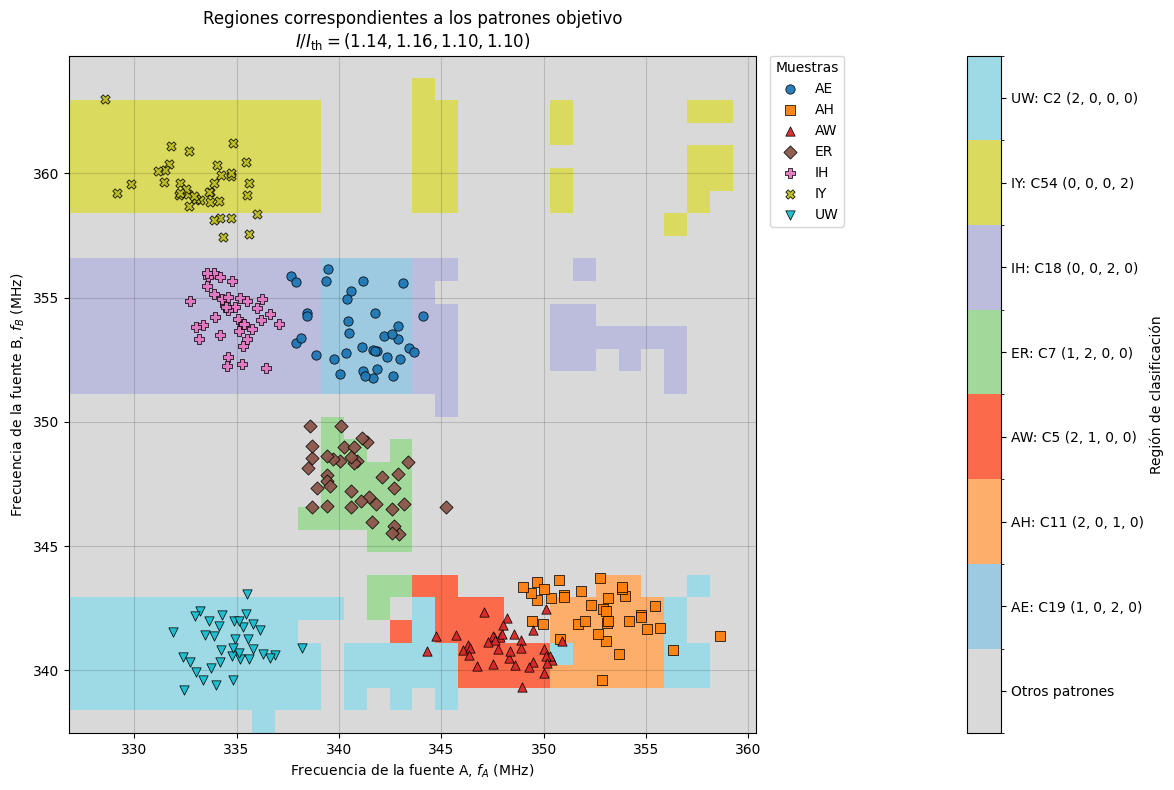

Figura guardada como: mapa_patrones_objetivo_penalizacion.png


In [ ]:
################################################################
#      Mapa simplificado de los siete patrones objetivo        #
################################################################

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

################################################################
#             Códigos de los patrones objetivo                #
################################################################

codigos_objetivo={vocal: int(codificacion(patrones_objetivo[vocal])) for vocal in vocales}
patrones_objetivo_limpios={vocal: tuple(int(valor) for valor in patrones_objetivo[vocal]) for vocal in vocales}

print("Patrones objetivo:")

for vocal in vocales:
    print(f"{vocal.upper()}: "f"C{codigos_objetivo[vocal]} "f"{patrones_objetivo_limpios[vocal]}")


################################################################
#             Simplificación de los patrones                  #
################################################################

mapa_objetivos=np.zeros_like(mapa_codigos, dtype=int)

for indice, vocal in enumerate(vocales, start=1):
    codigo=codigos_objetivo[vocal]
    mapa_objetivos[mapa_codigos==codigo]=indice


################################################################
#                        Colores                               #
################################################################

colores_regiones=[
    "#D9D9D9",  # Otros patrones
    "#9ECAE1",  # AE
    "#FDAE6B",  # AH
    "#FB6A4A",  # AW
    "#A1D99B",  # ER
    "#BCBDDC",  # IH
    "#DADA5E",  # IY
    "#9EDAE5"   # UW
]

colores_puntos={
    "ae": "#1F77B4",
    "ah": "#FF7F0E",
    "aw": "#D62728",
    "er": "#8C564B",
    "ih": "#E377C2",
    "iy": "#BCBD22",
    "uw": "#17BECF"
}

marcadores_vocales={
    "ae": "o",
    "ah": "s",
    "aw": "^",
    "er": "D",
    "ih": "P",
    "iy": "X",
    "uw": "v"
}

mapa_colores_objetivo=ListedColormap(colores_regiones)
norma_colores=BoundaryNorm(np.arange(-0.5, len(colores_regiones)+0.5, 1), mapa_colores_objetivo.N)

################################################################
#                         Figura                               #
################################################################

figura, eje=plt.subplots(figsize=(12, 8))
imagen=eje.imshow(mapa_objetivos, origin="lower", aspect="auto", extent=[f_A_val[0], f_A_val[-1], f_B_val[0], f_B_val[-1]], cmap=mapa_colores_objetivo, norm=norma_colores, interpolation="nearest")
eje.set_xlabel(r"Frecuencia de la fuente A, $f_A$ (MHz)")
eje.set_ylabel(r"Frecuencia de la fuente B, $f_B$ (MHz)")
texto_corrientes=", ".join(f"{corriente:.2f}" for corriente in Irazon_mapa)
eje.set_title("Regiones correspondientes a los patrones objetivo\n"rf"$I/I_{{\mathrm{{th}}}}="rf"({texto_corrientes})$")

################################################################
#                   Nubes de vocales                           #
################################################################

for vocal in vocales:
    f_A_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 0])
    f_B_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 1])
    eje.scatter(f_A_vocal, f_B_vocal, s=45, marker=marcadores_vocales[vocal], color=colores_puntos[vocal], edgecolors="black", linewidths=0.55, alpha=0.95, label=vocal.upper(), zorder=3)    

################################################################
#                 Leyenda y barra de colores                   #
################################################################

eje.legend(title="Muestras", loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
etiquetas_regiones=["Otros patrones"]

for vocal in vocales:
    etiquetas_regiones.append(f"{vocal.upper()}: "f"C{codigos_objetivo[vocal]} "f"{patrones_objetivo_limpios[vocal]}")

patrones_objetivo_limpios={
    vocal: tuple(int(valor) for valor in patrones_objetivo[vocal]) for vocal in vocales}

print("Patrones objetivo:")

for vocal in vocales:
    print(f"{vocal.upper()}: "f"C{codigos_objetivo[vocal]} "f"{patrones_objetivo_limpios[vocal]}")

barra_colores=figura.colorbar(imagen, ax=eje, ticks=np.arange(len(etiquetas_regiones)), pad=0.20)
barra_colores.ax.set_yticklabels(etiquetas_regiones)
barra_colores.set_label("Región de clasificación")
eje.grid(alpha=0.15,color="black")
figura.tight_layout()


################################################################
#                     Guardado                                 #
################################################################

figura.savefig("mapa_patrones_objetivo_penalizacion.png", dpi=300,bbox_inches="tight")

plt.show()

print("Figura guardada como: ""mapa_patrones_objetivo_penalizacion.png")

Corrientes utilizadas:
[1.14 1.16 1.1  1.1 ]

Frecuencias naturales adimensionales:
[0.97359735 0.99419603 1.0126755  1.03272848]

Frecuencias naturales en MHz:
[340.75907285 347.96860927 354.43642384 361.45496689]

Tolerancia adimensional: 0.0014285714285714286
Tolerancia física: 0.5 MHz

Rango del mapa:
Fuente A: 326.82 a 360.38 MHz
Fuente B: 337.47 a 364.74 MHz
Fila 1/30 terminada | 30/900 puntos | fila: 15.1 min | ETA: 7.30 h
Fila 2/30 terminada | 60/900 puntos | fila: 16.0 min | ETA: 7.26 h
Fila 3/30 terminada | 90/900 puntos | fila: 18.1 min | ETA: 7.39 h
Fila 4/30 terminada | 120/900 puntos | fila: 18.9 min | ETA: 7.39 h
Fila 5/30 terminada | 150/900 puntos | fila: 21.4 min | ETA: 7.47 h
Fila 6/30 terminada | 180/900 puntos | fila: 21.2 min | ETA: 7.39 h
Fila 7/30 terminada | 210/900 puntos | fila: 19.8 min | ETA: 7.15 h
Fila 8/30 terminada | 240/900 puntos | fila: 16.4 min | ETA: 6.73 h
Fila 9/30 terminada | 270/900 puntos | fila: 14.2 min | ETA: 6.27 h
Fila 10/30 terminada | 3

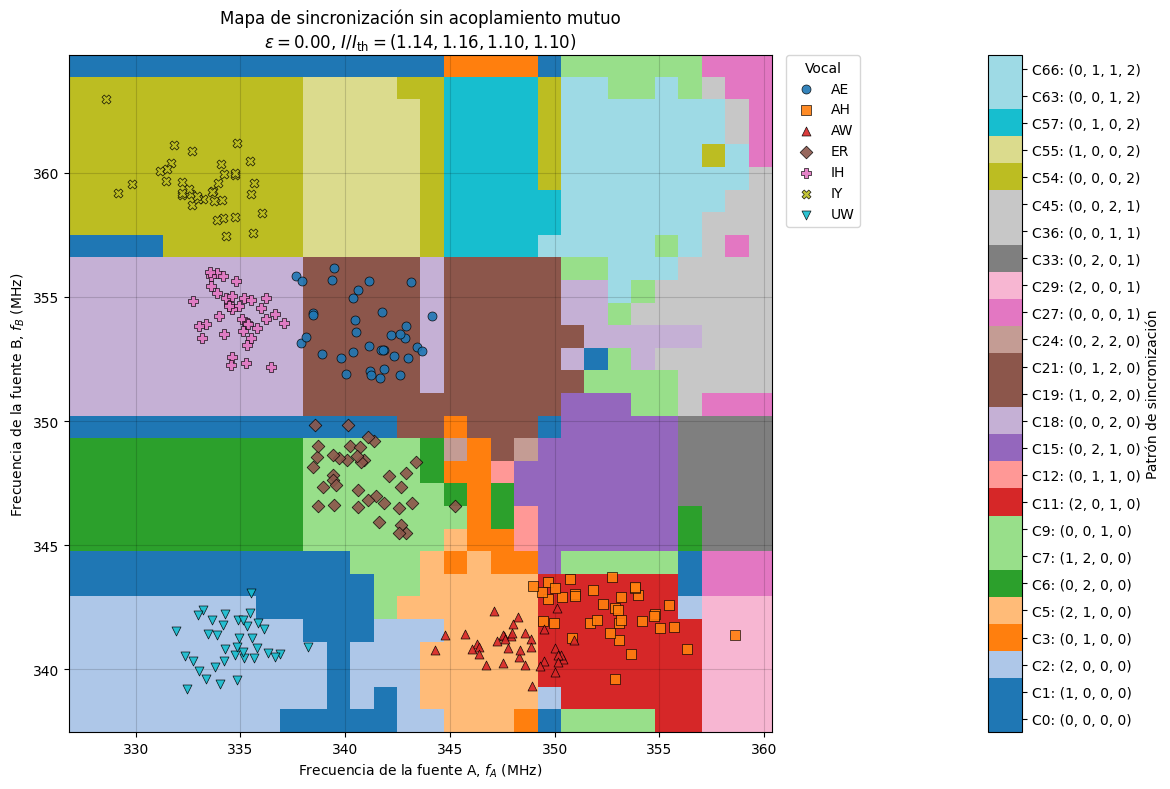


Mapa entrenado guardado correctamente en:
mapa_entrenado_30x30_epsilon_0.npz


In [29]:
################################################################
#         Mapa sin acoplamiento mutuo entre los STNOs          #
################################################################

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

################################################################
#                  Parámetros del mapa                         #
################################################################

epsilon=0
Num_puntos_mapa=30
tau_final_mapa=5000
pasos_mapa=10000
frecuencia_referencia=350.0
tolerancia_mapa=0.5/frecuencia_referencia
Irazon_mapa=np.array(Irazon_final_paper,dtype=float).copy()
s_ss_mapa=np.sqrt(np.maximum(Irazon_mapa-1.0, 0.0)/Q)
Omega_libres_mapa=Omega_0*(1.0+N_0*s_ss_mapa**2)

f_libres_mapa=(frecuencia_referencia*Omega_libres_mapa)
print("Corrientes utilizadas:")
print(Irazon_mapa)
print("\nFrecuencias naturales adimensionales:")
print(Omega_libres_mapa)
print("\nFrecuencias naturales en MHz:")
print(f_libres_mapa)
print("\nTolerancia adimensional:",tolerancia_mapa)
print("Tolerancia física:",frecuencia_referencia*tolerancia_mapa,"MHz") 

################################################################
#          Rango que contiene todas las vocales                #
################################################################

todas_entradas=np.vstack([dataset_vocales[vocal] for vocal in vocales])
margen_mapa=0.005
Omega_A_min=(todas_entradas[:, 0].min()-margen_mapa)
Omega_A_max=(todas_entradas[:, 0].max()+margen_mapa)
Omega_B_min=(todas_entradas[:, 1].min()-margen_mapa)
Omega_B_max=(todas_entradas[:, 1].max()+margen_mapa)
Omega_A_val=np.linspace(Omega_A_min, Omega_A_max, Num_puntos_mapa)
Omega_B_val=np.linspace(Omega_B_min, Omega_B_max, Num_puntos_mapa)

f_A_val=frecuencia_referencia*Omega_A_val
f_B_val=frecuencia_referencia*Omega_B_val

print("\nRango del mapa:")
print(f"Fuente A: "f"{f_A_val[0]:.2f} a "f"{f_A_val[-1]:.2f} MHz")
print(f"Fuente B: "f"{f_B_val[0]:.2f} a "f"{f_B_val[-1]:.2f} MHz")

################################################################
#                  Construcción del mapa                       #
################################################################

mapa_codigos=np.zeros((len(Omega_B_val), len(Omega_A_val)),dtype=int)
puntos_totales=(len(Omega_A_val)*len(Omega_B_val))
contador=0
inicio_mapa=time.perf_counter()

for j, Omega_B_actual in enumerate(Omega_B_val):
    inicio_fila=time.perf_counter()
    for i, Omega_A_actual in enumerate(Omega_A_val):
        patron_actual=Patron_particular(Omega_A_actual, Omega_B_actual, Irazon_mapa, tau_final=tau_final_mapa, numero_puntos=pasos_mapa, tolerancia=tolerancia_mapa)
        codigo_actual=codificacion(patron_actual)
        mapa_codigos[j, i]=codigo_actual
        contador += 1

    tiempo_transcurrido=(time.perf_counter()-inicio_mapa)
    tiempo_fila=(time.perf_counter()-inicio_fila)
    velocidad=contador/tiempo_transcurrido
    puntos_restantes=(puntos_totales-contador)
    segundos_restantes=(puntos_restantes/velocidad)

    print(f"Fila {j + 1}/{len(Omega_B_val)} terminada | "f"{contador}/{puntos_totales} puntos | "f"fila: {tiempo_fila/60:.1f} min | "f"ETA: {segundos_restantes/3600:.2f} h")

tiempo_total_mapa=(time.perf_counter()-inicio_mapa)

print("\nMapa entrenado terminado correctamente.")
print(f"Tiempo total: "f"{tiempo_total_mapa/3600:.2f} h")

################################################################
#                   Patrones encontrados                       #
################################################################

codigos_presentes=np.unique(mapa_codigos)
patrones_encontrados={int(codigo): decodificar_patron(codigo) for codigo in codigos_presentes}

print("\nPatrones de sincronización encontrados:")

for codigo, patron in sorted(patrones_encontrados.items()):
    print(f"Código {codigo:2d}: {patron}")


################################################################
#           Preparación de los colores del mapa                #
################################################################

indice_colores=np.zeros_like(mapa_codigos)

for indice, codigo in enumerate(codigos_presentes):
    indice_colores[mapa_codigos == codigo]=indice

colores_regiones=plt.cm.tab20(np.linspace(0.0, 1.0, len(codigos_presentes)))
mapa_colores=ListedColormap(colores_regiones)

################################################################
#       Gráfico del mapa entrenado con las siete vocales       #
################################################################

figura, eje=plt.subplots(figsize=(12, 8))
imagen=eje.imshow(indice_colores, origin="lower", aspect="auto", extent=[f_A_val[0], f_A_val[-1], f_B_val[0], f_B_val[-1]], cmap=mapa_colores, interpolation="nearest", vmin=-0.5, vmax=len(codigos_presentes)-0.5)
eje.set_xlabel(r"Frecuencia de la fuente A, $f_A$ (MHz)")
eje.set_ylabel(r"Frecuencia de la fuente B, $f_B$ (MHz)")
texto_corrientes=", ".join(f"{corriente:.2f}" for corriente in Irazon_mapa)
eje.set_title("Mapa de sincronización sin acoplamiento mutuo\n"rf"$\epsilon={epsilon:.2f}$, "rf"$I/I_{{\mathrm{{th}}}}="rf"({texto_corrientes})$")

################################################################
#                  Nubes de las vocales                        #
################################################################

colores_vocales=plt.cm.tab10(np.linspace(0.0,1.0,len(vocales)))
marcadores_vocales=["o", "s", "^", "D", "P", "X", "v"]

for vocal, color, marcador in zip(vocales, colores_vocales, marcadores_vocales):
    f_A_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 0])  #Conversión de las entradas adimensionales a MHz
    f_B_vocal=(frecuencia_referencia*dataset_vocales[vocal][:, 1])
    eje.scatter(f_A_vocal, f_B_vocal, s=42, marker=marcador, color=color, edgecolors="black", linewidths=0.5, alpha=0.9, label=vocal.upper(), zorder=3)


################################################################
#             Leyenda y barra de patrones                      #
################################################################

eje.legend(title="Vocal", loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
etiquetas_patrones=[(f"C{int(codigo)}: "f"{decodificar_patron(codigo)}") for codigo in codigos_presentes]
barra_colores=figura.colorbar(imagen, ax=eje, ticks=np.arange(len(codigos_presentes)), pad=0.20)
barra_colores.ax.set_yticklabels(etiquetas_patrones)
barra_colores.set_label("Patrón de sincronización")
eje.grid(alpha=0.15, color="black")
figura.tight_layout()
plt.show()

################################################################
#              Guardado del mapa entrenado                     #
################################################################

np.savez_compressed(
    "mapa_entrenado_30x30_epsilon_0.npz",
    mapa_codigos=mapa_codigos,
    Omega_A_val=Omega_A_val,
    Omega_B_val=Omega_B_val,
    f_A_val=f_A_val,
    f_B_val=f_B_val,
    Irazon_mapa=Irazon_mapa,
    Omega_libres_mapa=Omega_libres_mapa,
    f_libres_mapa=f_libres_mapa,
    tolerancia_mapa=tolerancia_mapa,
    frecuencia_referencia=frecuencia_referencia,
    tau_final_mapa=tau_final_mapa,
    pasos_mapa=pasos_mapa,
    tiempo_total_mapa=tiempo_total_mapa)

print("\nMapa entrenado guardado correctamente en:")

print("mapa_entrenado_30x30_epsilon_0.npz")

In [22]:
datos_epsilon_0=np.load(
    "mapa_entrenado_30x30_epsilon_0.npz"
)

mapa_codigos=datos_epsilon_0["mapa_codigos"]
f_A_val=datos_epsilon_0["f_A_val"]
f_B_val=datos_epsilon_0["f_B_val"]
Irazon_mapa=datos_epsilon_0["Irazon_mapa"]

frecuencia_referencia=float(
    datos_epsilon_0["frecuencia_referencia"]
)

epsilon=0.0

Patrones objetivo:
AE: C19 (1, 0, 2, 0)
AH: C11 (2, 0, 1, 0)
AW: C5 (2, 1, 0, 0)
ER: C7 (1, 2, 0, 0)
IH: C18 (0, 0, 2, 0)
IY: C54 (0, 0, 0, 2)
UW: C2 (2, 0, 0, 0)


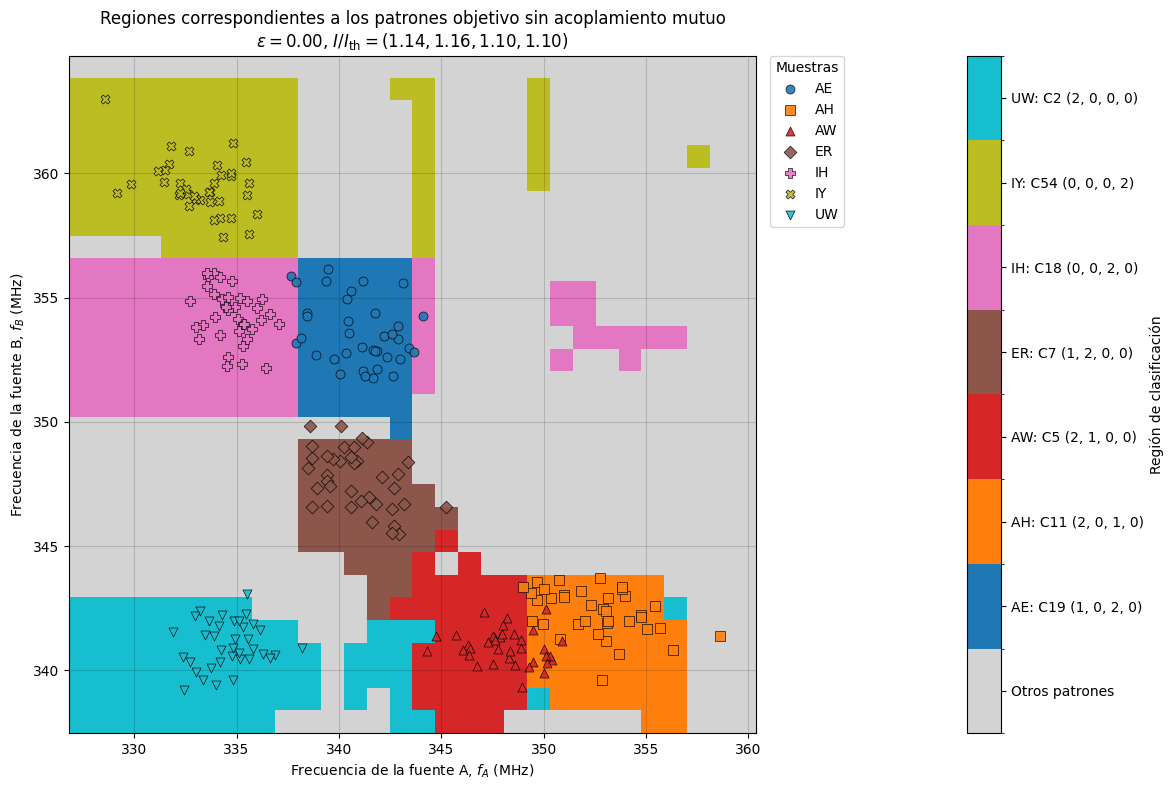

In [23]:

################################################################
#      Mapa de regiones correspondientes a patrones objetivo   #
#                    para epsilon = 0                          #
################################################################

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

################################################################
#        Asociación entre vocales y patrones objetivo          #
################################################################

# Código correspondiente al patrón objetivo de cada vocal
codigos_objetivo={
    vocal: int(codificacion(patrones_objetivo[vocal]))
    for vocal in vocales
}

print("Patrones objetivo:")

for vocal in vocales:
    patron_limpio=tuple(
        int(valor)
        for valor in patrones_objetivo[vocal]
    )

    print(
        f"{vocal.upper()}: "
        f"C{codigos_objetivo[vocal]} "
        f"{patron_limpio}"
    )

################################################################
#          Clasificación simplificada de cada región           #
################################################################

# Valor 0: patrón no objetivo
# Valores 1 a 7: patrones objetivo de las siete vocales
mapa_objetivos=np.zeros_like(
    mapa_codigos,
    dtype=int
)

for indice, vocal in enumerate(vocales, start=1):

    codigo=codigos_objetivo[vocal]

    mapa_objetivos[
        mapa_codigos == codigo
    ]=indice

################################################################
#                     Colores del mapa                         #
################################################################

# Los colores de las regiones y de las muestras serán iguales
colores_vocales=plt.cm.tab10(
    np.linspace(
        0.0,
        1.0,
        len(vocales)
    )
)

# Gris para todos los patrones que no son objetivo
colores_mapa=[
    "lightgray",
    *colores_vocales
]

mapa_colores=ListedColormap(
    colores_mapa
)

limites_colores=np.arange(
    -0.5,
    len(vocales)+1.5,
    1.0
)

norma_colores=BoundaryNorm(
    limites_colores,
    mapa_colores.N
)

################################################################
#                        Gráfico                               #
################################################################

figura, eje=plt.subplots(
    figsize=(12, 8)
)

imagen=eje.imshow(
    mapa_objetivos,
    origin="lower",
    aspect="auto",
    extent=[
        f_A_val[0],
        f_A_val[-1],
        f_B_val[0],
        f_B_val[-1]
    ],
    cmap=mapa_colores,
    norm=norma_colores,
    interpolation="nearest"
)

eje.set_xlabel(
    r"Frecuencia de la fuente A, $f_A$ (MHz)"
)

eje.set_ylabel(
    r"Frecuencia de la fuente B, $f_B$ (MHz)"
)

texto_corrientes=", ".join(
    f"{corriente:.2f}"
    for corriente in Irazon_mapa
)

eje.set_title(
    "Regiones correspondientes a los patrones objetivo "
    "sin acoplamiento mutuo\n"
    rf"$\epsilon={epsilon:.2f}$, "
    rf"$I/I_{{\mathrm{{th}}}}=({texto_corrientes})$"
)

################################################################
#                  Muestras de las vocales                     #
################################################################

marcadores_vocales=[
    "o",
    "s",
    "^",
    "D",
    "P",
    "X",
    "v"
]

for vocal, color, marcador in zip(
    vocales,
    colores_vocales,
    marcadores_vocales
):

    f_A_vocal=(
        frecuencia_referencia
        *dataset_vocales[vocal][:, 0]
    )

    f_B_vocal=(
        frecuencia_referencia
        *dataset_vocales[vocal][:, 1]
    )

    eje.scatter(
        f_A_vocal,
        f_B_vocal,
        s=42,
        marker=marcador,
        color=color,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9,
        label=vocal.upper(),
        zorder=3
    )

################################################################
#                   Leyenda de muestras                        #
################################################################

eje.legend(
    title="Muestras",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

################################################################
#                  Barra de clasificación                      #
################################################################

etiquetas_barra=[
    "Otros patrones"
]

for vocal in vocales:

    codigo=codigos_objetivo[vocal]

    patron_limpio=tuple(
        int(valor)
        for valor in patrones_objetivo[vocal]
    )

    etiquetas_barra.append(
        f"{vocal.upper()}: "
        f"C{codigo} "
        f"{patron_limpio}"
    )

barra_colores=figura.colorbar(
    imagen,
    ax=eje,
    ticks=np.arange(len(vocales)+1),
    boundaries=limites_colores,
    pad=0.20
)

barra_colores.ax.set_yticklabels(
    etiquetas_barra
)

barra_colores.set_label(
    "Región de clasificación"
)

eje.grid(
    alpha=0.15,
    color="black"
)

figura.tight_layout()

################################################################
#                  Guardado de la figura                       #
################################################################

plt.savefig(
    "mapa_patrones_objetivo_epsilon_0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()